# NDT7 EDA — Thailand Broadband & Mobile/Cellular (Combined)

Full exploratory analysis of Thailand NDT7 (M-Lab) data, mirroring the structure of
`notebooks/ookla/thailand_eda.ipynb` (Fixed Broadband + Mobile/Cellular) and
`notebooks/ndt7/cambodia_eda.ipynb` / `vietnam_eda.ipynb`'s combined-format layout, so results
are directly comparable section-by-section across all three NDT7 countries and against Ookla.

Replaces the older ad-hoc Thai NDT7 pipeline (`ndt7_eda.ipynb`, `ndt7_edav2.ipynb`,
`ndt7_mobile_eda.ipynb`, BKK-district-specific notebooks) with the same lean
prep-notebook → province-quarterly-CSV → combined-EDA-notebook pattern used for Vietnam and
Cambodia.

**Input:** `data/exports/ndt7_thailand_province_quarterly.csv` (Broadband) and
`data/exports/ndt7_thailand_mobile_province_quarterly.csv` (Mobile) — both produced by
`thailand_ndt7_prep.ipynb` (tile-binned at Ookla's zoom-16 resolution, `is_reliable` computed
with the same `total_tests>=100 & n_tiles>=5` threshold used by every Ookla country notebook
and the Vietnam/Cambodia NDT7 prep notebooks, merged with
`data/reference/province_reference.csv`). This notebook does no raw-data processing — it
picks up where the prep notebook leaves off.

**Known result, stated up front:** Thailand's NDT7 volume (60.2M raw records — 31.0M
broadband, 29.2M cellular) is far larger than Vietnam's (24.7M) or Cambodia's (0.75M), so
reliability holds up much better under the same `n_tiles>=5` threshold: **57.0% of Broadband
province-quarters reliable (517/907), 15.4% of Mobile (81/526)** — compare Vietnam's 28.6%
Broadband / 1.0% Mobile, and Cambodia's 0% / 0%. Sections below still carry the same guard
clauses as Vietnam/Cambodia for consistency and to fail gracefully on any individual sparse
province-quarter, even though most of this notebook should render normally.

## Province Reference Data

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../data/reference/province_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = (prov_ref['gdp_per_capita_thb_2021'] / 31.0).round(0)

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))

Provinces loaded: 77
Regions: ['Bangkok & Vicinity', 'Central', 'Eastern', 'Northeastern', 'Northern', 'Southern', 'Western']

             province_en             region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
      Bangkok Metropolis Bangkok & Vicinity   5456000             3488               1957179.52              1
           Amnat Charoen       Northeastern    372000              113                253897.82              4
               Ang Thong            Central    269000              283                468881.20              3
               Bueng Kan       Northeastern    419000              105                264149.56              4
                Buri Ram       Northeastern   1566000              155                265879.60              4
            Chachoengsao            Eastern    733000              142               1319396.70              2
                Chai Nat            Central    314000              131                447066.18 

### Population and GDP by Region — Summary

In [2]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())

                    provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                           
Eastern                     8         5.24        147.0            1220404.0              39368.0
Bangkok & Vicinity          6        10.91       1490.0            1093207.0              35265.0
Central                     6         2.97        212.0             744085.0              24002.0
Western                     6         3.81        163.0             523585.0              16890.0
Southern                   14         9.52        182.0             439166.0              14167.0
Northern                   17        11.89         72.0             356387.0              11496.0
Northeastern               20        21.62        129.0             280136.0               9037.0


### GDP per Capita vs Population Density — by Region

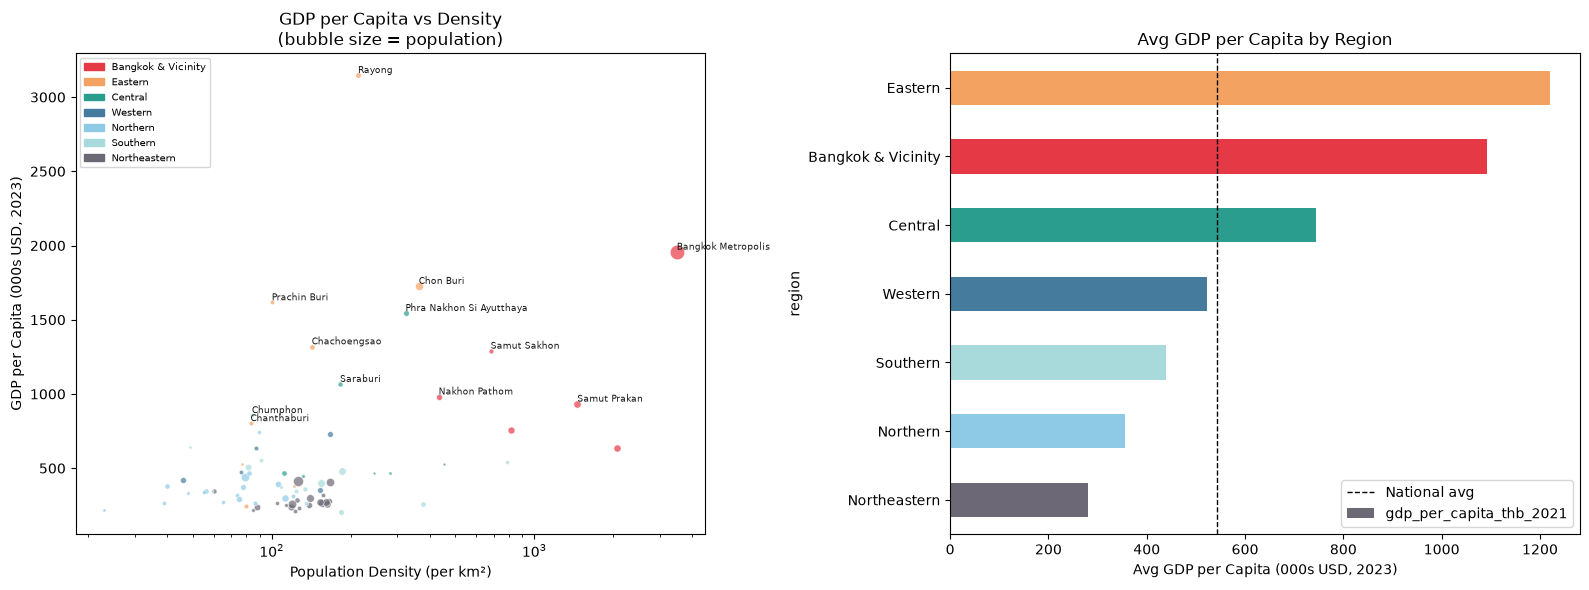

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern': '#f4a261',
    'Central': '#2a9d8f',
    'Western': '#457b9d',
    'Northern': '#8ecae6',
    'Southern': '#a8dadc',
    'Northeastern': '#6d6875',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()
os.makedirs('../../outputs/ndt7/thailand', exist_ok=True)
plt.savefig('../../outputs/ndt7/thailand/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()

### Internet Tier Distribution — Assumptions Map

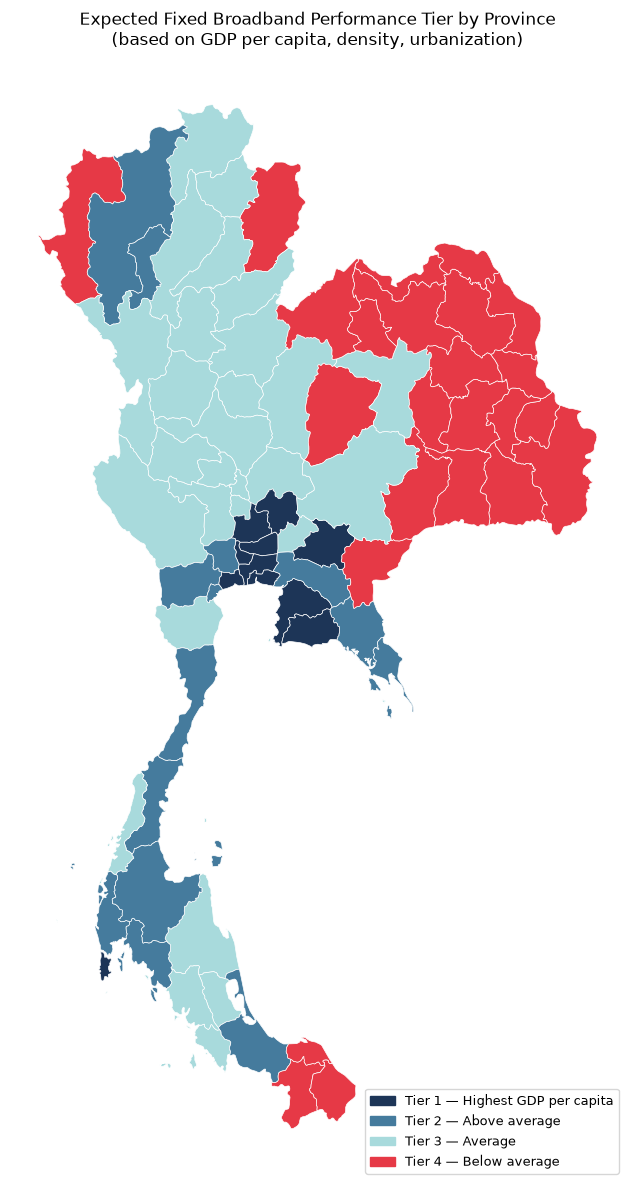

In [4]:
GEOJSON_PATH = '../../data/geo/thailand_provinces.geojson'
thailand_gdf = gpd.read_file(GEOJSON_PATH).to_crs(4326)

tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()
geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig('../../outputs/ndt7/thailand/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()

### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [5]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))

=== TOP 10 by GDP per Capita ===
             province_en             region  pop_2024  gdp_per_capita_thb_2021  internet_tier
                  Rayong            Eastern    782000               3147422.75              1
      Bangkok Metropolis Bangkok & Vicinity   5456000               1957179.52              1
               Chon Buri            Eastern   1636000               1726754.27              1
            Prachin Buri            Eastern    501000               1616351.17              1
Phra Nakhon Si Ayutthaya            Central    823000               1544117.75              1
            Chachoengsao            Eastern    733000               1319396.70              2
            Samut Sakhon Bangkok & Vicinity    591000               1289926.65              1
                Saraburi            Central    639000               1066220.56              1
           Nakhon Pathom Bangkok & Vicinity    926000                981679.12              2
            Samut Prakan Ba

---
# Part 1 — Broadband

## Full EDA — NDT7 Broadband, Thailand (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [6]:
import os
os.makedirs('../../outputs/ndt7/thailand/', exist_ok=True)

import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../data/exports/ndt7_thailand_province_quarterly.csv'
GEOJSON  = '../../data/geo/thailand_provinces.geojson'
PROV_REF = prov_ref  # loaded in shared setup above

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (907, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  77 (of 77 in reference — NDT7 has zero test volume for the rest)


In [7]:
# is_reliable already computed upstream (thailand_ndt7_prep.ipynb, same total_tests>=100 & n_tiles>=5 threshold)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\n57.0% of province-quarters reliable overall — the strongest NDT7 coverage of the three countries in this study, thanks to 60.2M raw records.")

Reliable province-quarters per label:
label
2023-Q1    67
2023-Q2    68
2023-Q3    65
2023-Q4    66
2024-Q1    63
2024-Q2    36
2024-Q3    24
2024-Q4    29
2025-Q1    27
2025-Q2    22
2025-Q3    26
2025-Q4    24

Overall reliable: 517 / 907 (57.0%)

57.0% of province-quarters reliable overall — the strongest NDT7 coverage of the three countries in this study, thanks to 60.2M raw records.


### 2. Data Quality — Coverage per Province

In [8]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 924 | Actual: 907 | Missing: 17

Every province has at least some NDT7 data in at least one quarter.

Low-test quarters (< 100 tests) — 31 of 907 province-quarter rows
            name   label  total_tests  n_tiles
        Yasothon 2025-Q1          3.0      1.0
           Phrae 2024-Q2          4.0      1.0
        Phangnga 2025-Q3         10.0      1.0
        Chumphon 2025-Q2         10.0      1.0
   Amnat Charoen 2025-Q2         11.0      1.0
        Yasothon 2025-Q4         11.0      1.0
    Mae Hong Son 2025-Q3         20.0      1.0
    Mae Hong Son 2024-Q2         25.0      1.0
     Phatthalung 2025-Q4         25.0      1.0
       Bueng Kan 2025-Q4         26.0      1.0
       Bueng Kan 2025-Q1         29.0      1.0
Nong Bua Lam Phu 2024-Q4         30.0      1.0
        Phangnga 2024-Q2         31.0      1.0
       Nong Khai 2024-Q3         37.0      1.0
      Phetchabun 2024-Q3         38.0      1.0


In [9]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 517 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

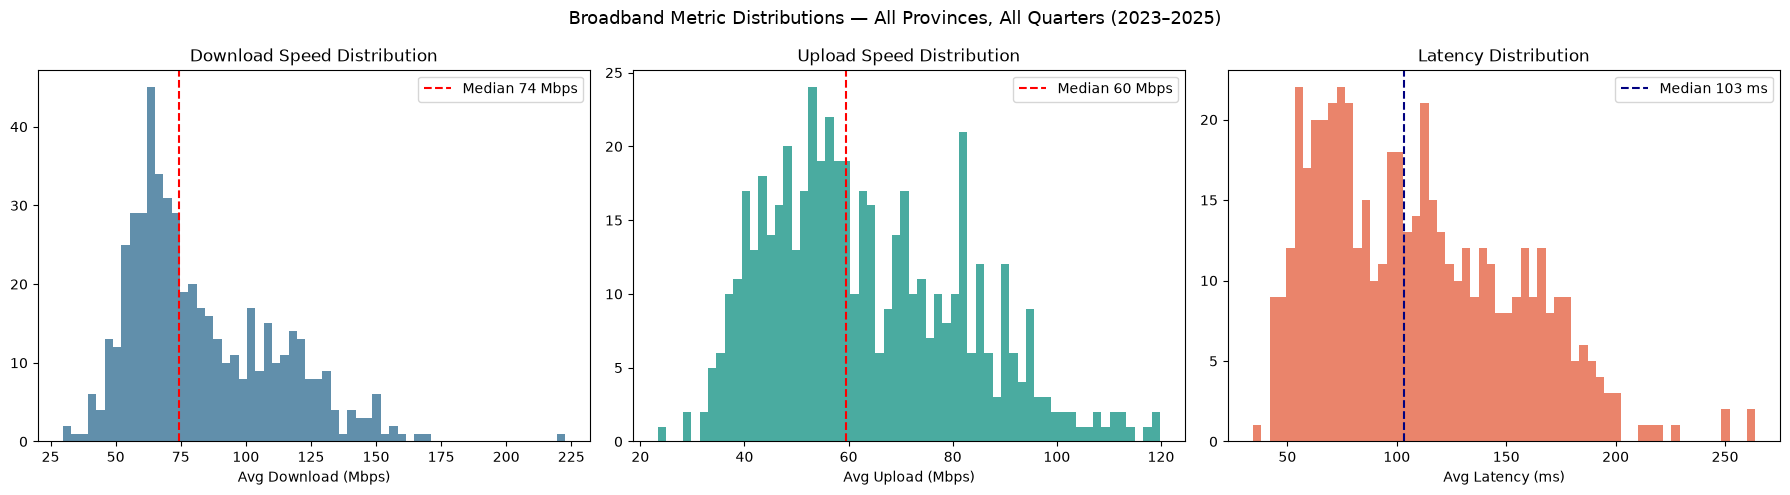

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      517.00      517.00         517.00       517.00
mean        83.17       63.16         109.35     32698.95
std         28.31       18.64          44.17    103745.75
min         29.71       23.36          34.22       316.00
25%         62.36       48.56          72.27      2041.00
50%         74.39       59.56         103.33      5404.00
75%        102.78       76.45         140.95     23555.00
max        222.54      119.80         263.64    952350.00


In [10]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../outputs/ndt7/thailand/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

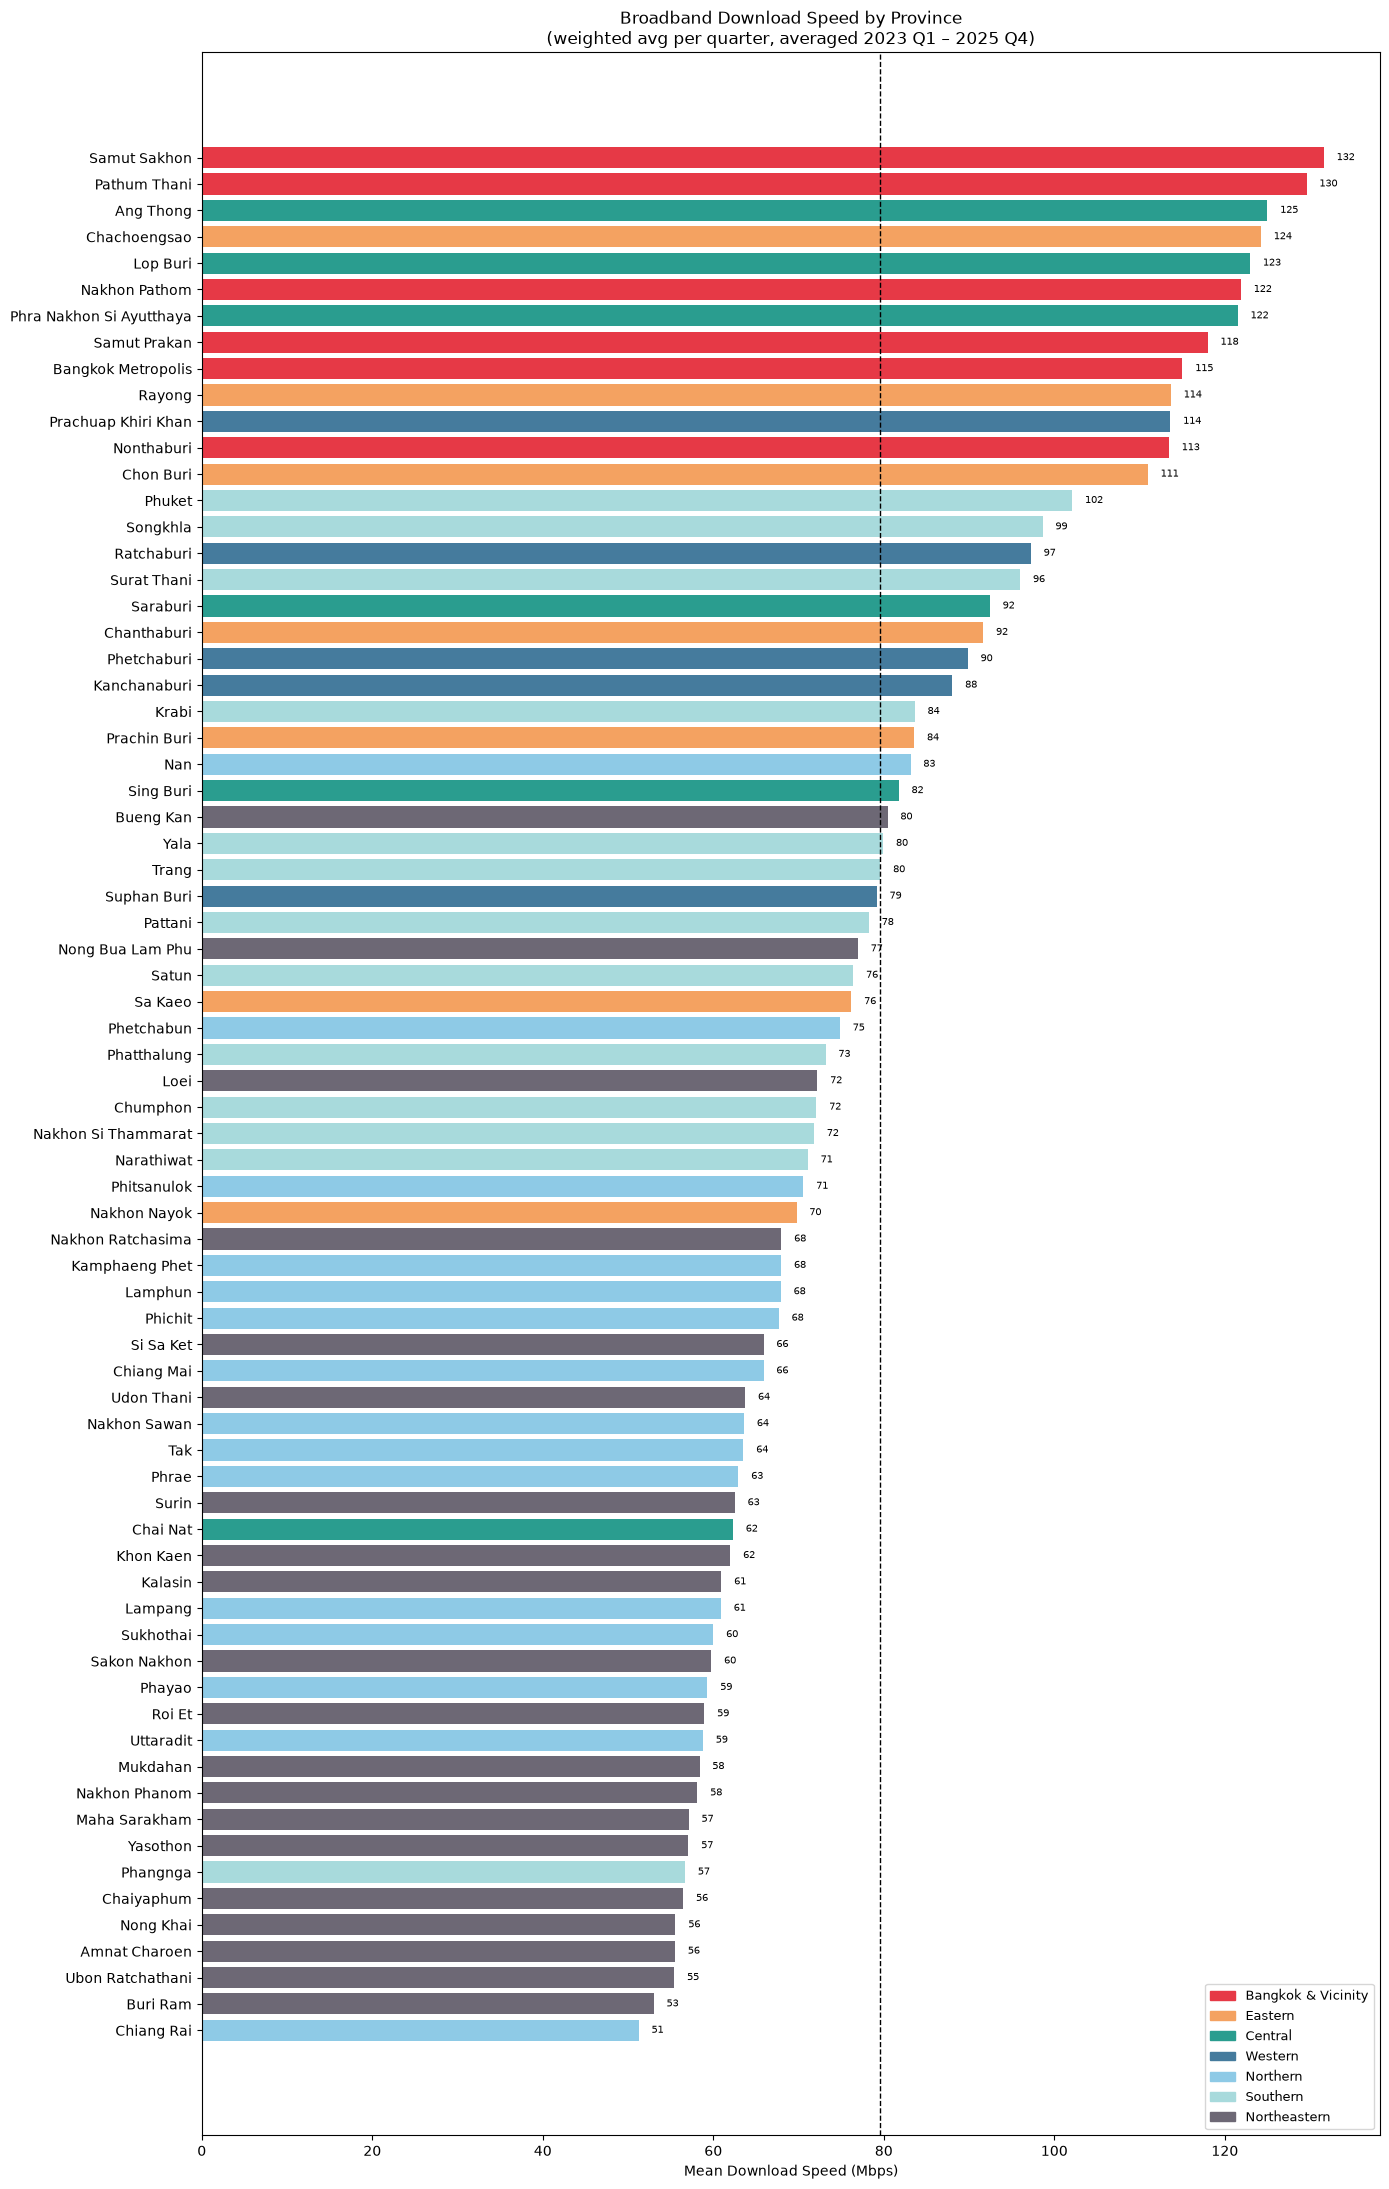

In [11]:
region_colors = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern': '#f4a261',
    'Central': '#2a9d8f',
    'Western': '#457b9d',
    'Northern': '#8ecae6',
    'Southern': '#a8dadc',
    'Northeastern': '#6d6875',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Broadband — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

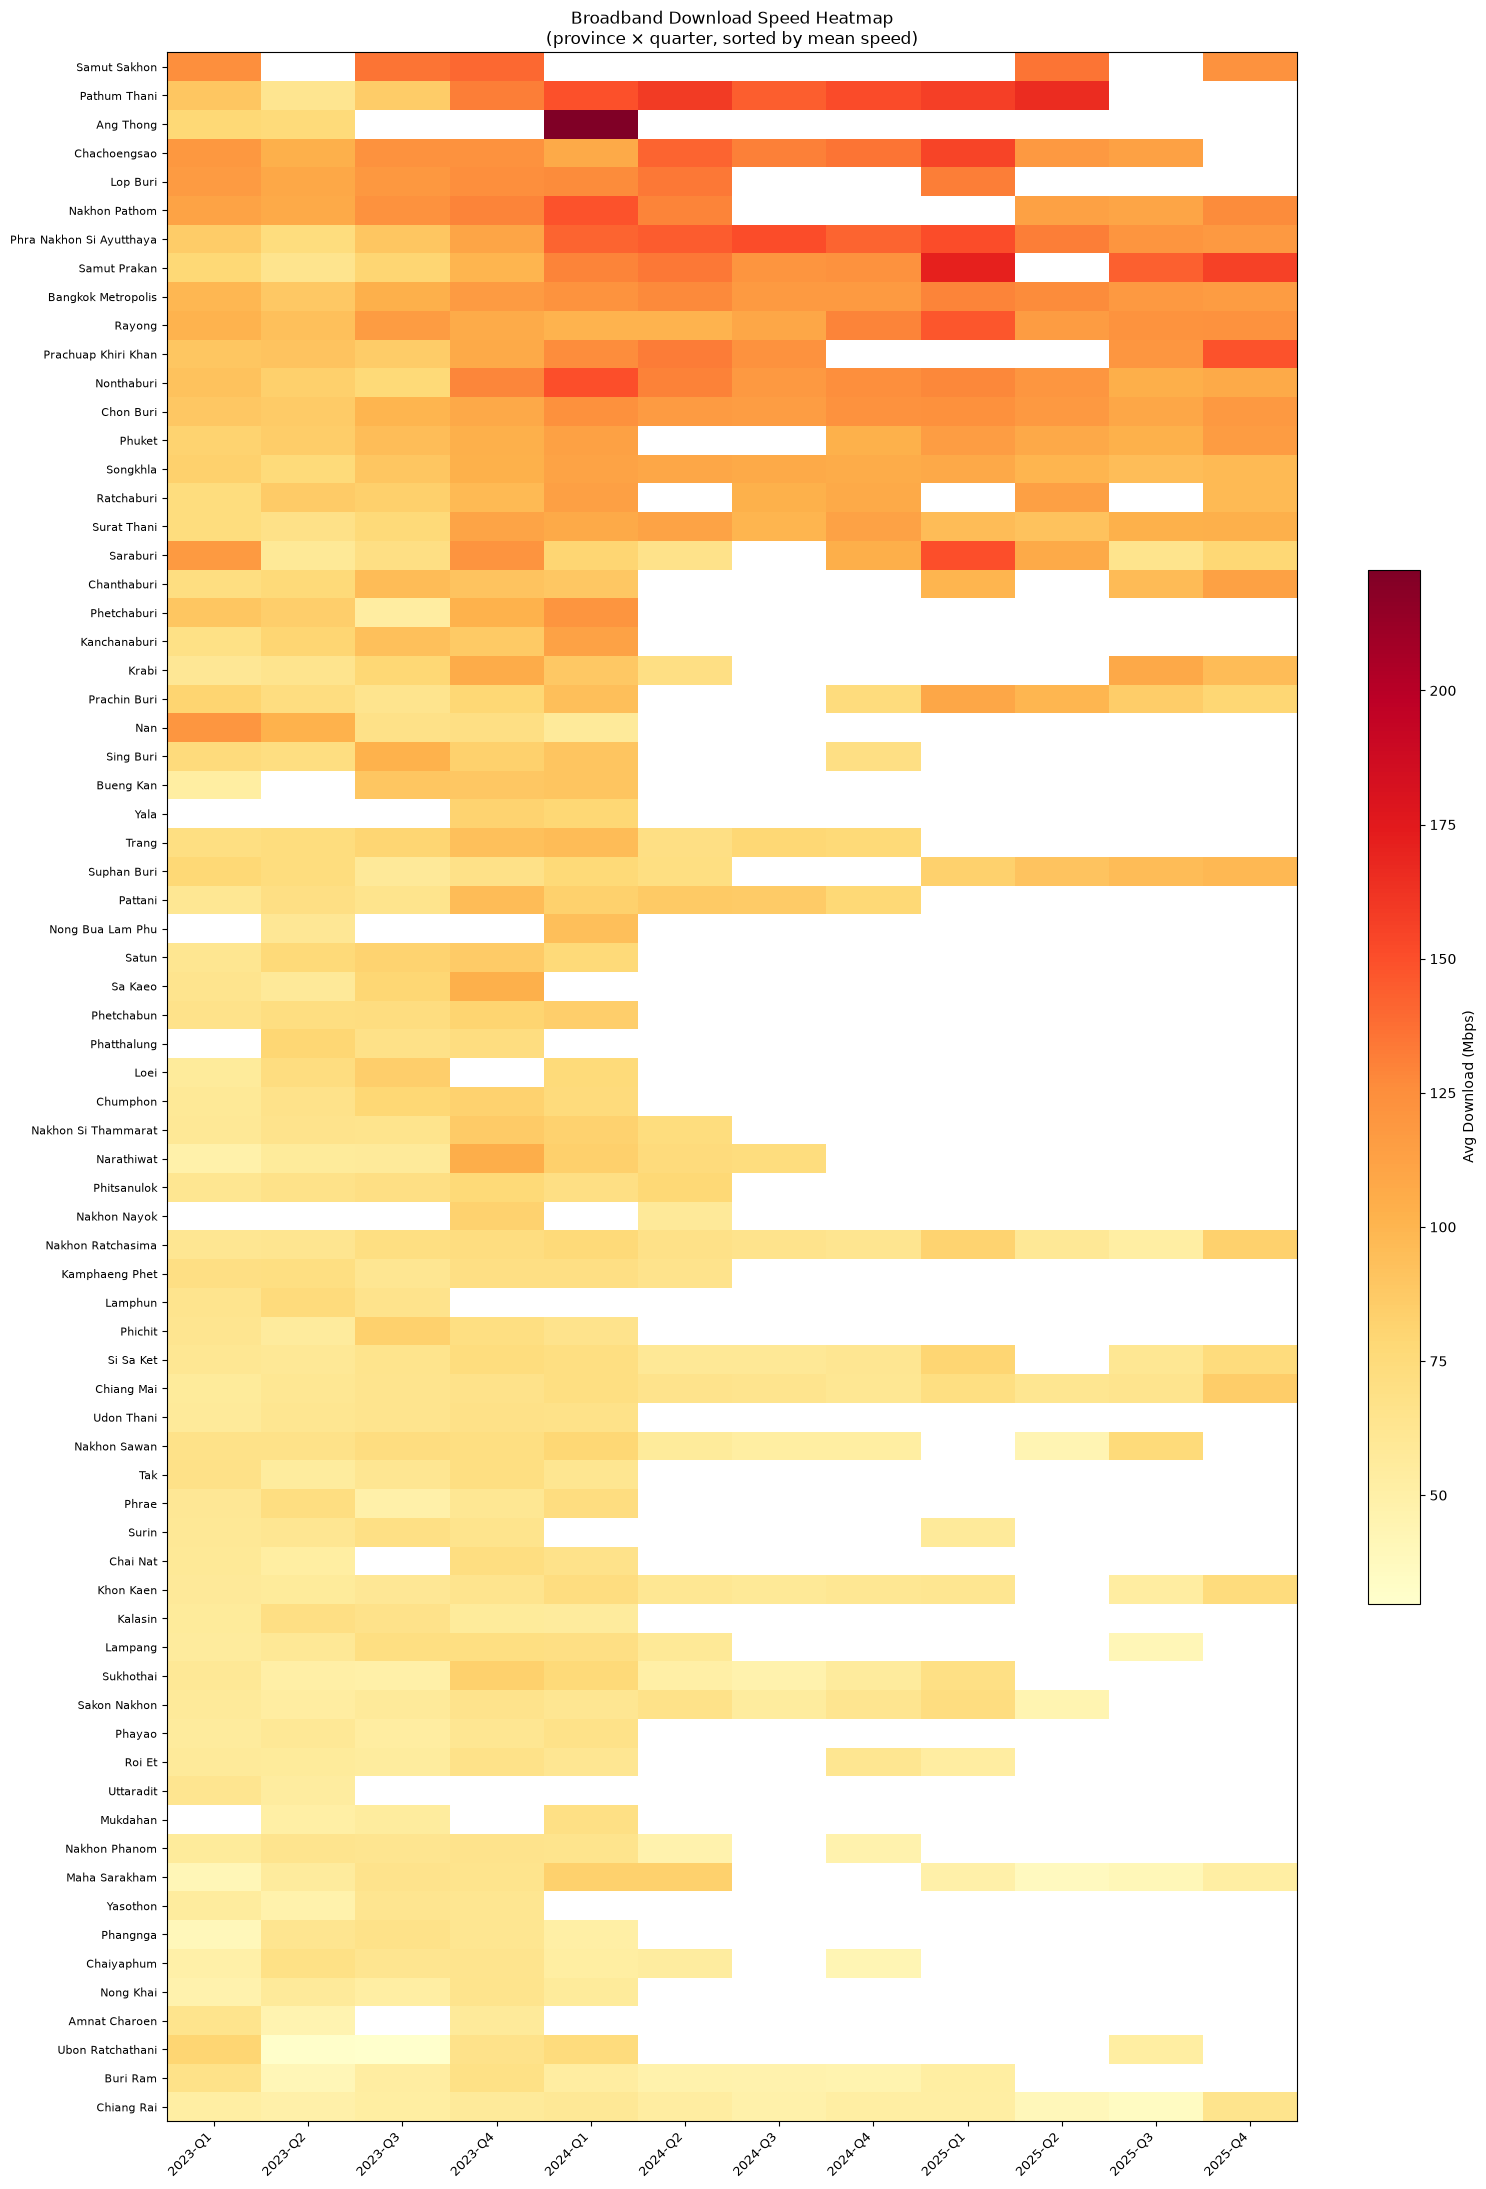

In [12]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

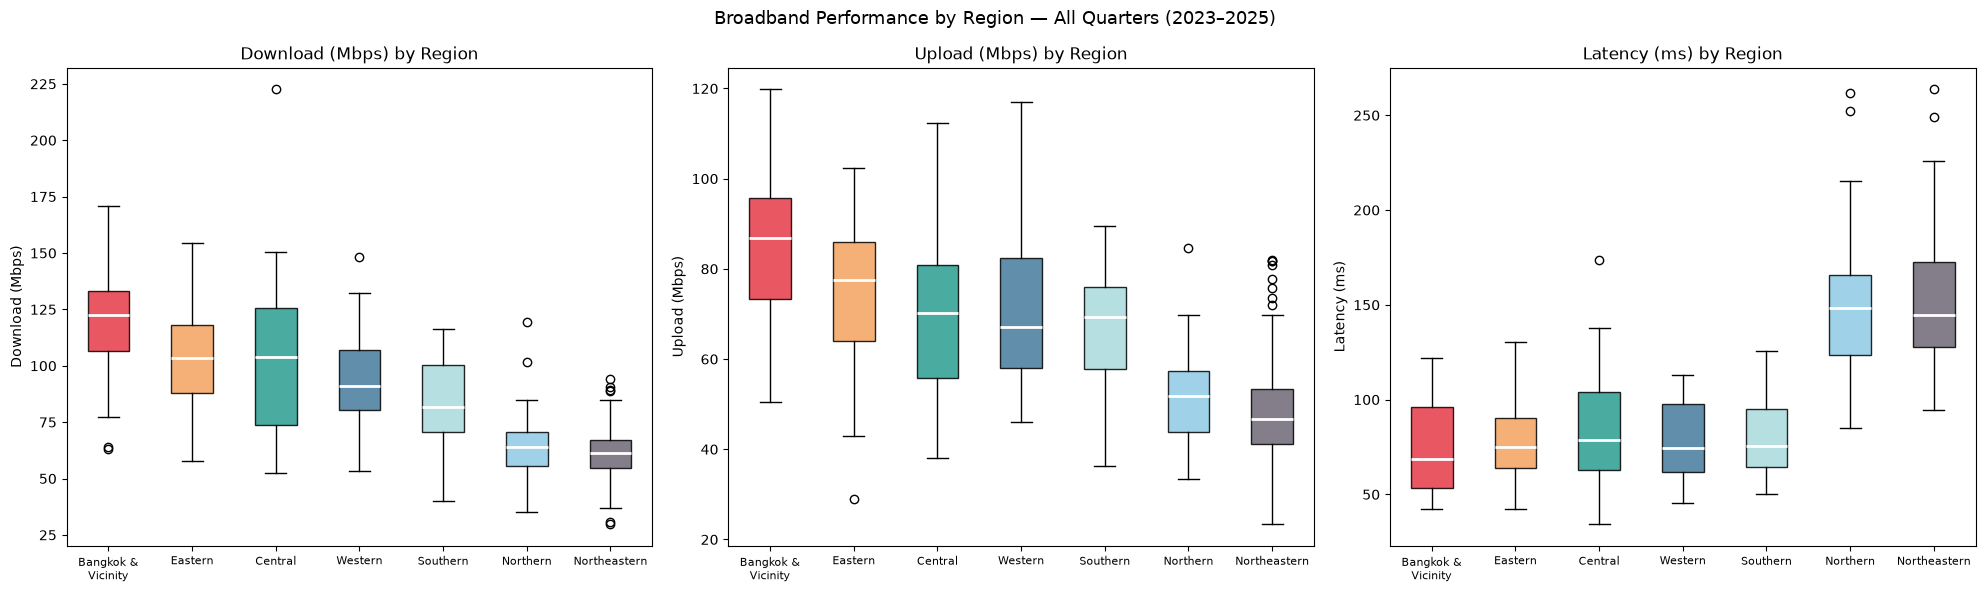

In [13]:
region_order = ['Bangkok & Vicinity', 'Eastern', 'Central', 'Western', 'Southern', 'Northern', 'Northeastern']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

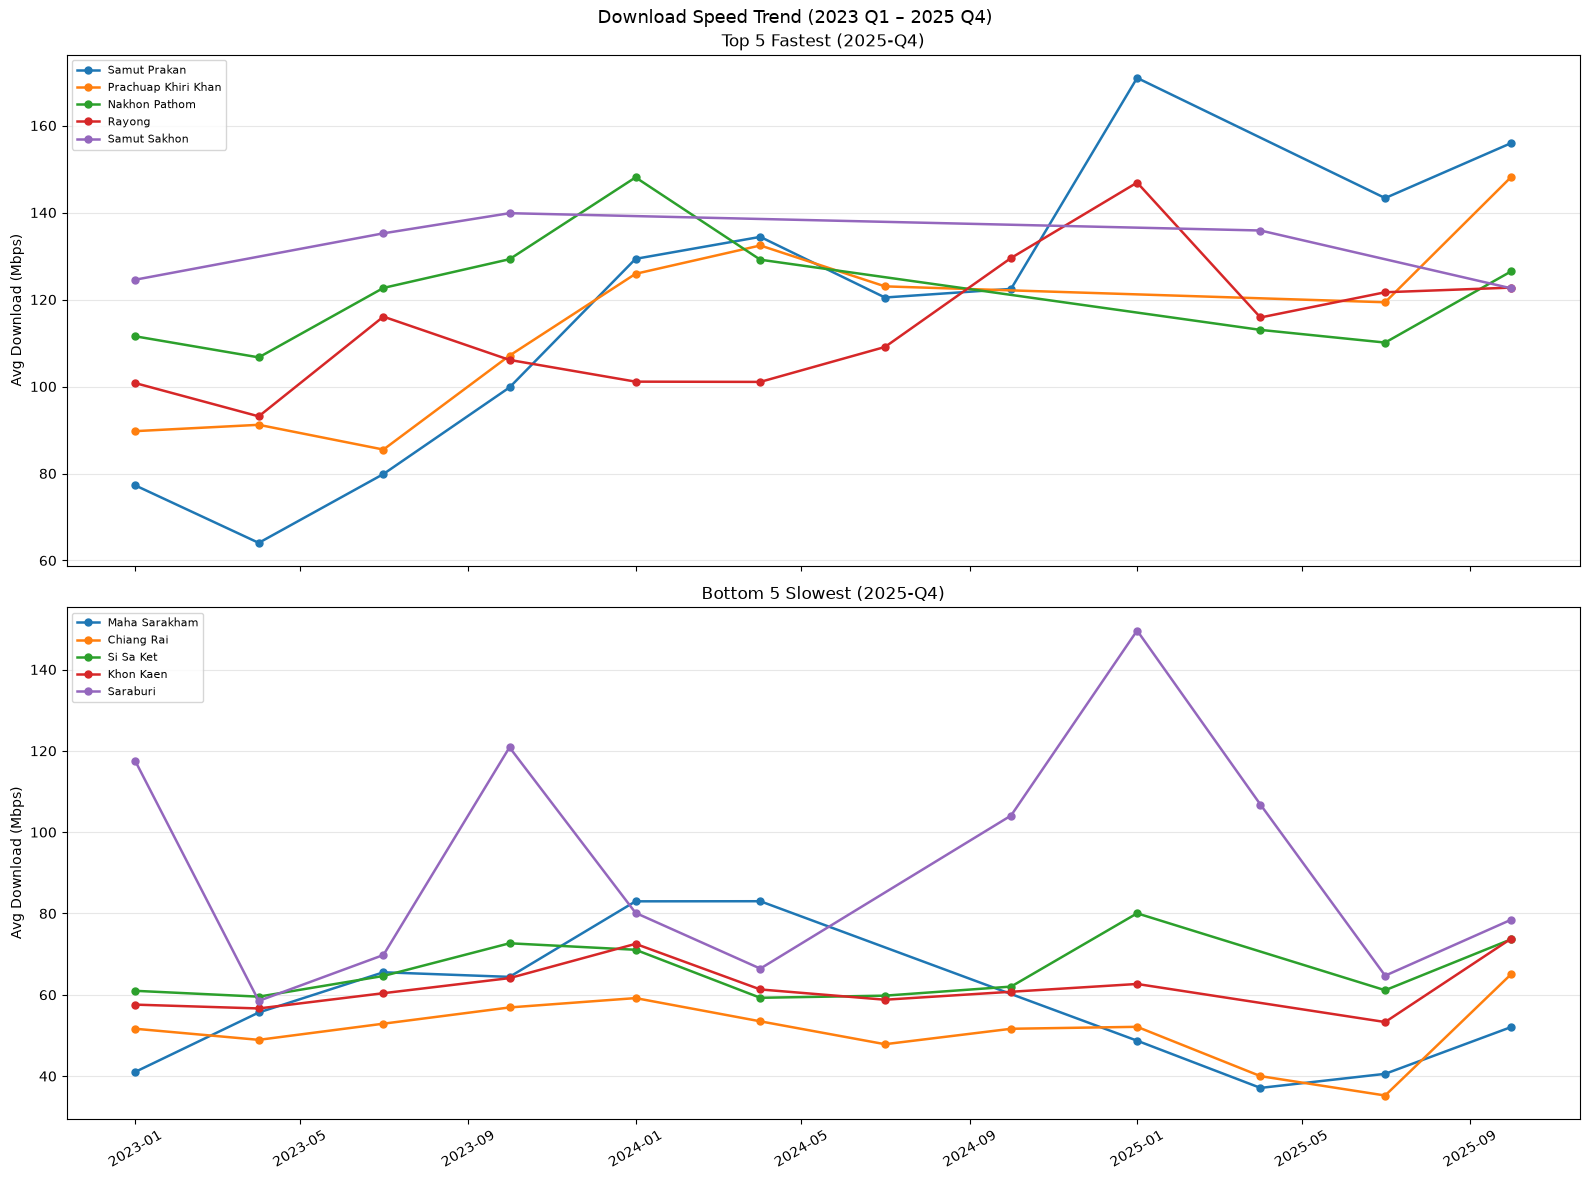

In [14]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

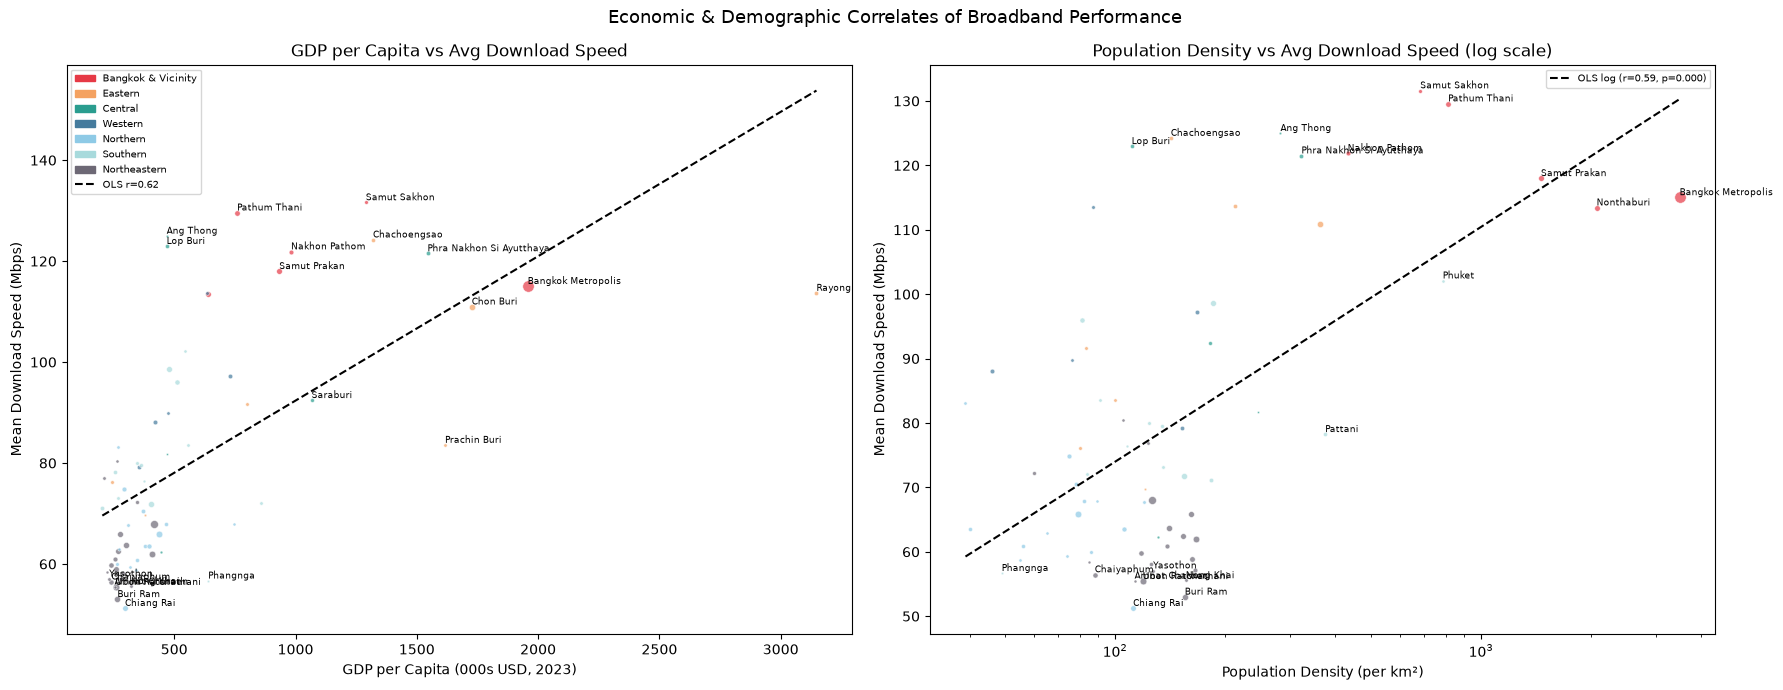

Pearson r (GDP vs download):     0.621  p=0.0000
Pearson r (log density vs download): 0.592  p=0.0000


In [15]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Broadband — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Broadband Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [16]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     17.15
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.13e-14
Time:                        10:59:16   Log-Likelihood:                -274.92
No. Observations:                  72   AIC:                             573.8
Df Residuals:                      60   BIC:                             601.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### 9. Upload/Download Ratio — Symmetry Check

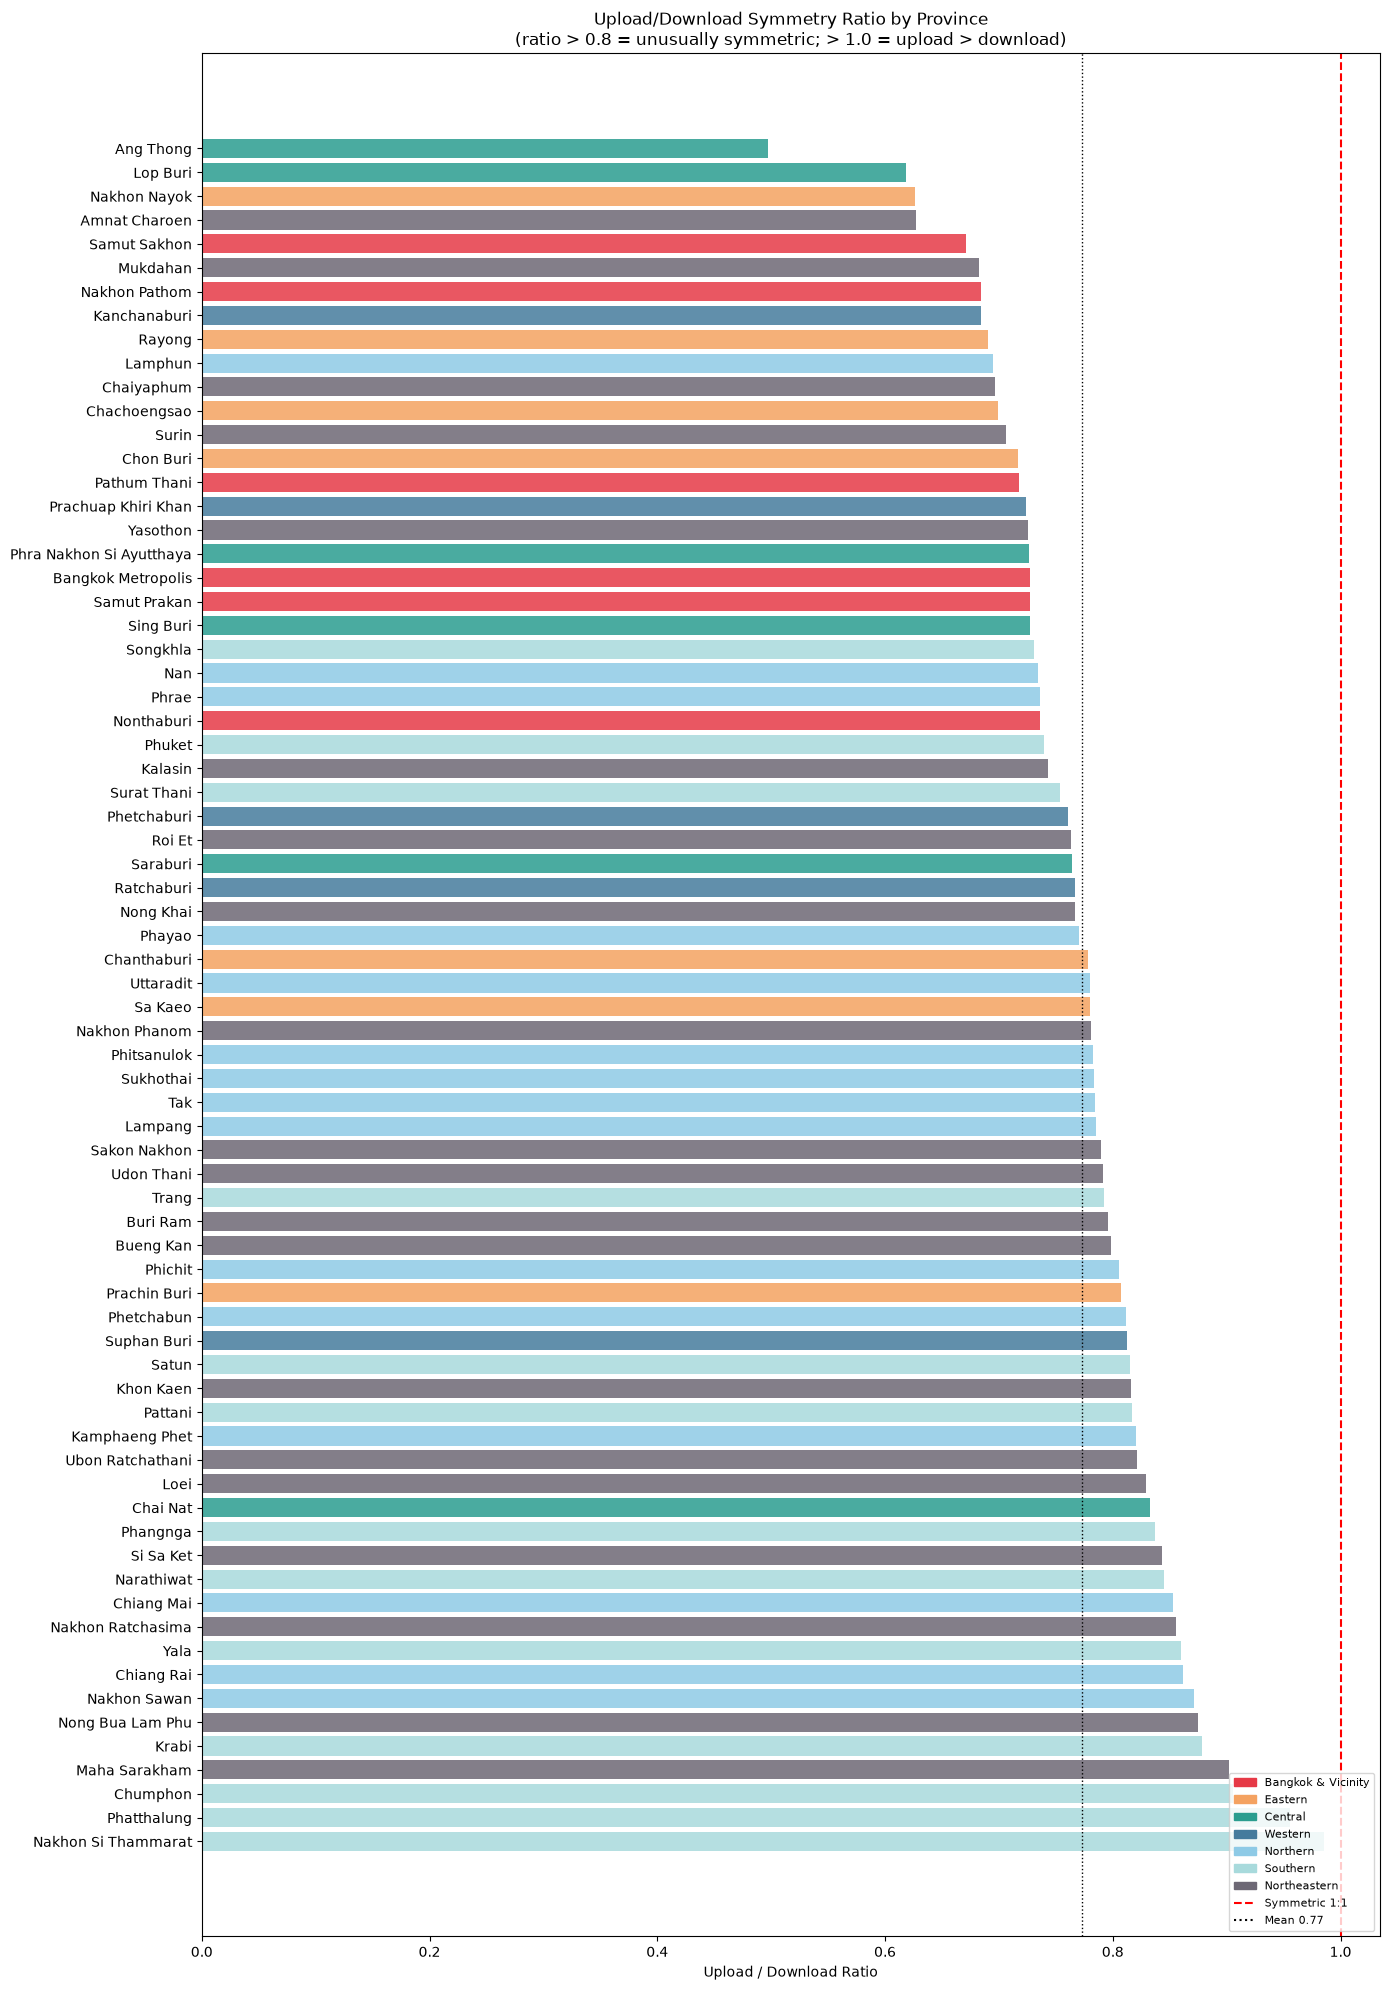

Provinces with UL/DL ratio > 0.8 (25):
               name       region  ul_dl_ratio
Nakhon Si Thammarat     Southern     0.985381
        Phatthalung     Southern     0.955920
           Chumphon     Southern     0.905723
      Maha Sarakham Northeastern     0.902035
              Krabi     Southern     0.878214
   Nong Bua Lam Phu Northeastern     0.874581
       Nakhon Sawan     Northern     0.871341
         Chiang Rai     Northern     0.861358
               Yala     Southern     0.859922
  Nakhon Ratchasima Northeastern     0.855710
         Chiang Mai     Northern     0.852828
         Narathiwat     Southern     0.845036
          Si Sa Ket Northeastern     0.843550
           Phangnga     Southern     0.836709
           Chai Nat      Central     0.832593
               Loei Northeastern     0.829527
   Ubon Ratchathani Northeastern     0.820988
     Kamphaeng Phet     Northern     0.820341
            Pattani     Southern     0.816460
          Khon Kaen Northeastern     0.81

In [17]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
    print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [18]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Broadband — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [19]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

                    name             region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
            Samut Sakhon Bangkok & Vicinity              1   131.62    88.31     80.80         0.67     9650.60               1289926.65
            Pathum Thani Bangkok & Vicinity              1   129.59    92.28     67.59         0.72    26018.10                759245.02
               Ang Thong            Central              3   124.99    46.18     94.25         0.50     2446.33                468881.20
            Chachoengsao            Eastern              2   124.24    86.57     68.89         0.70    12658.09               1319396.70
                Lop Buri            Central              3   122.97    75.81     75.27         0.62     8341.29                468881.20
           Nakhon Pathom Bangkok & Vicinity              2   121.89    83.21     85.86         0.68    38772.33                981679.12
Phra Nakhon Si Ayutthaya            Centr

### 13. UL/DL Symmetry — Fiber Penetration Evidence

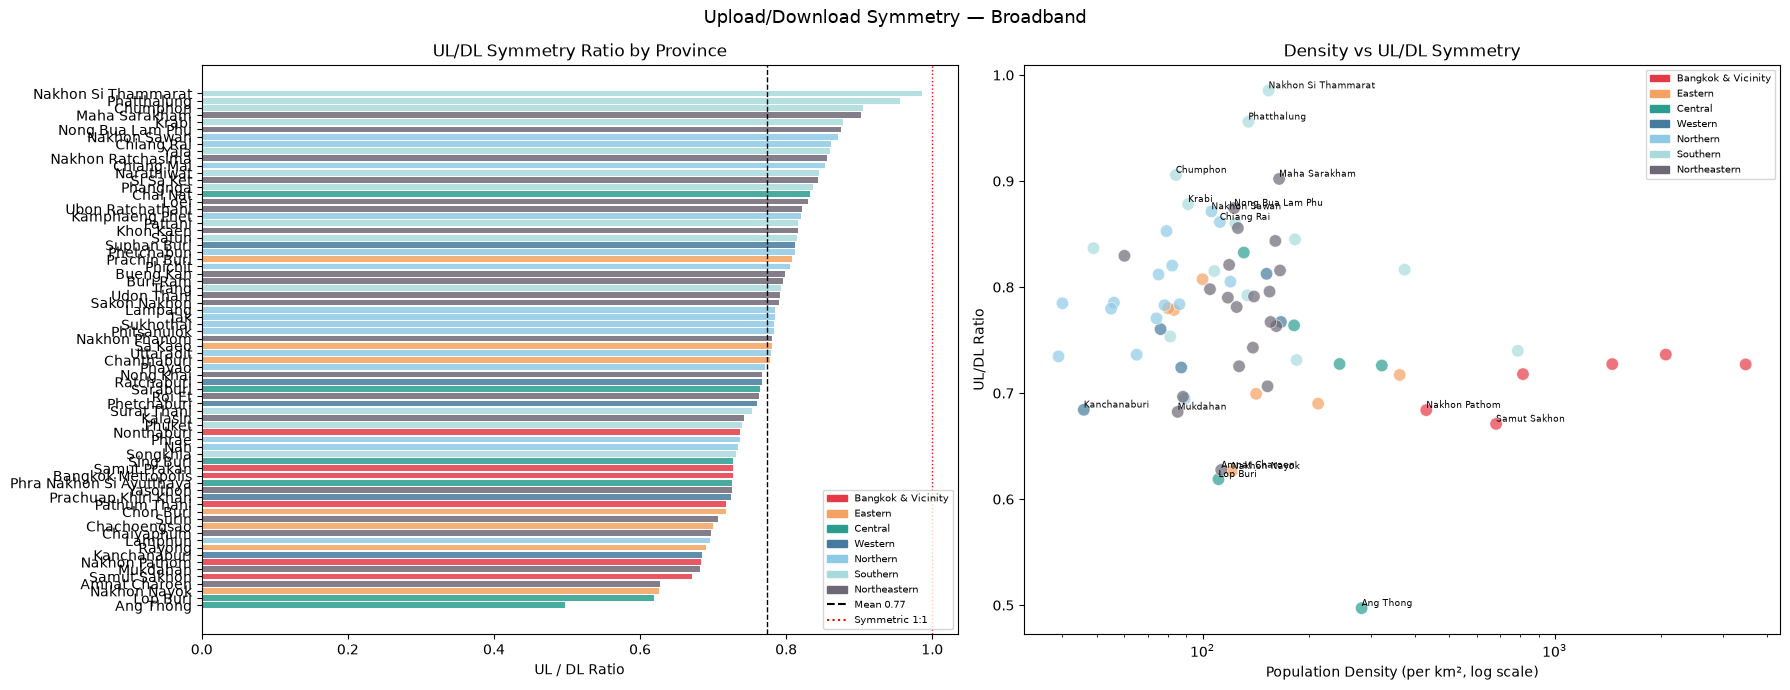

In [20]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Broadband', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

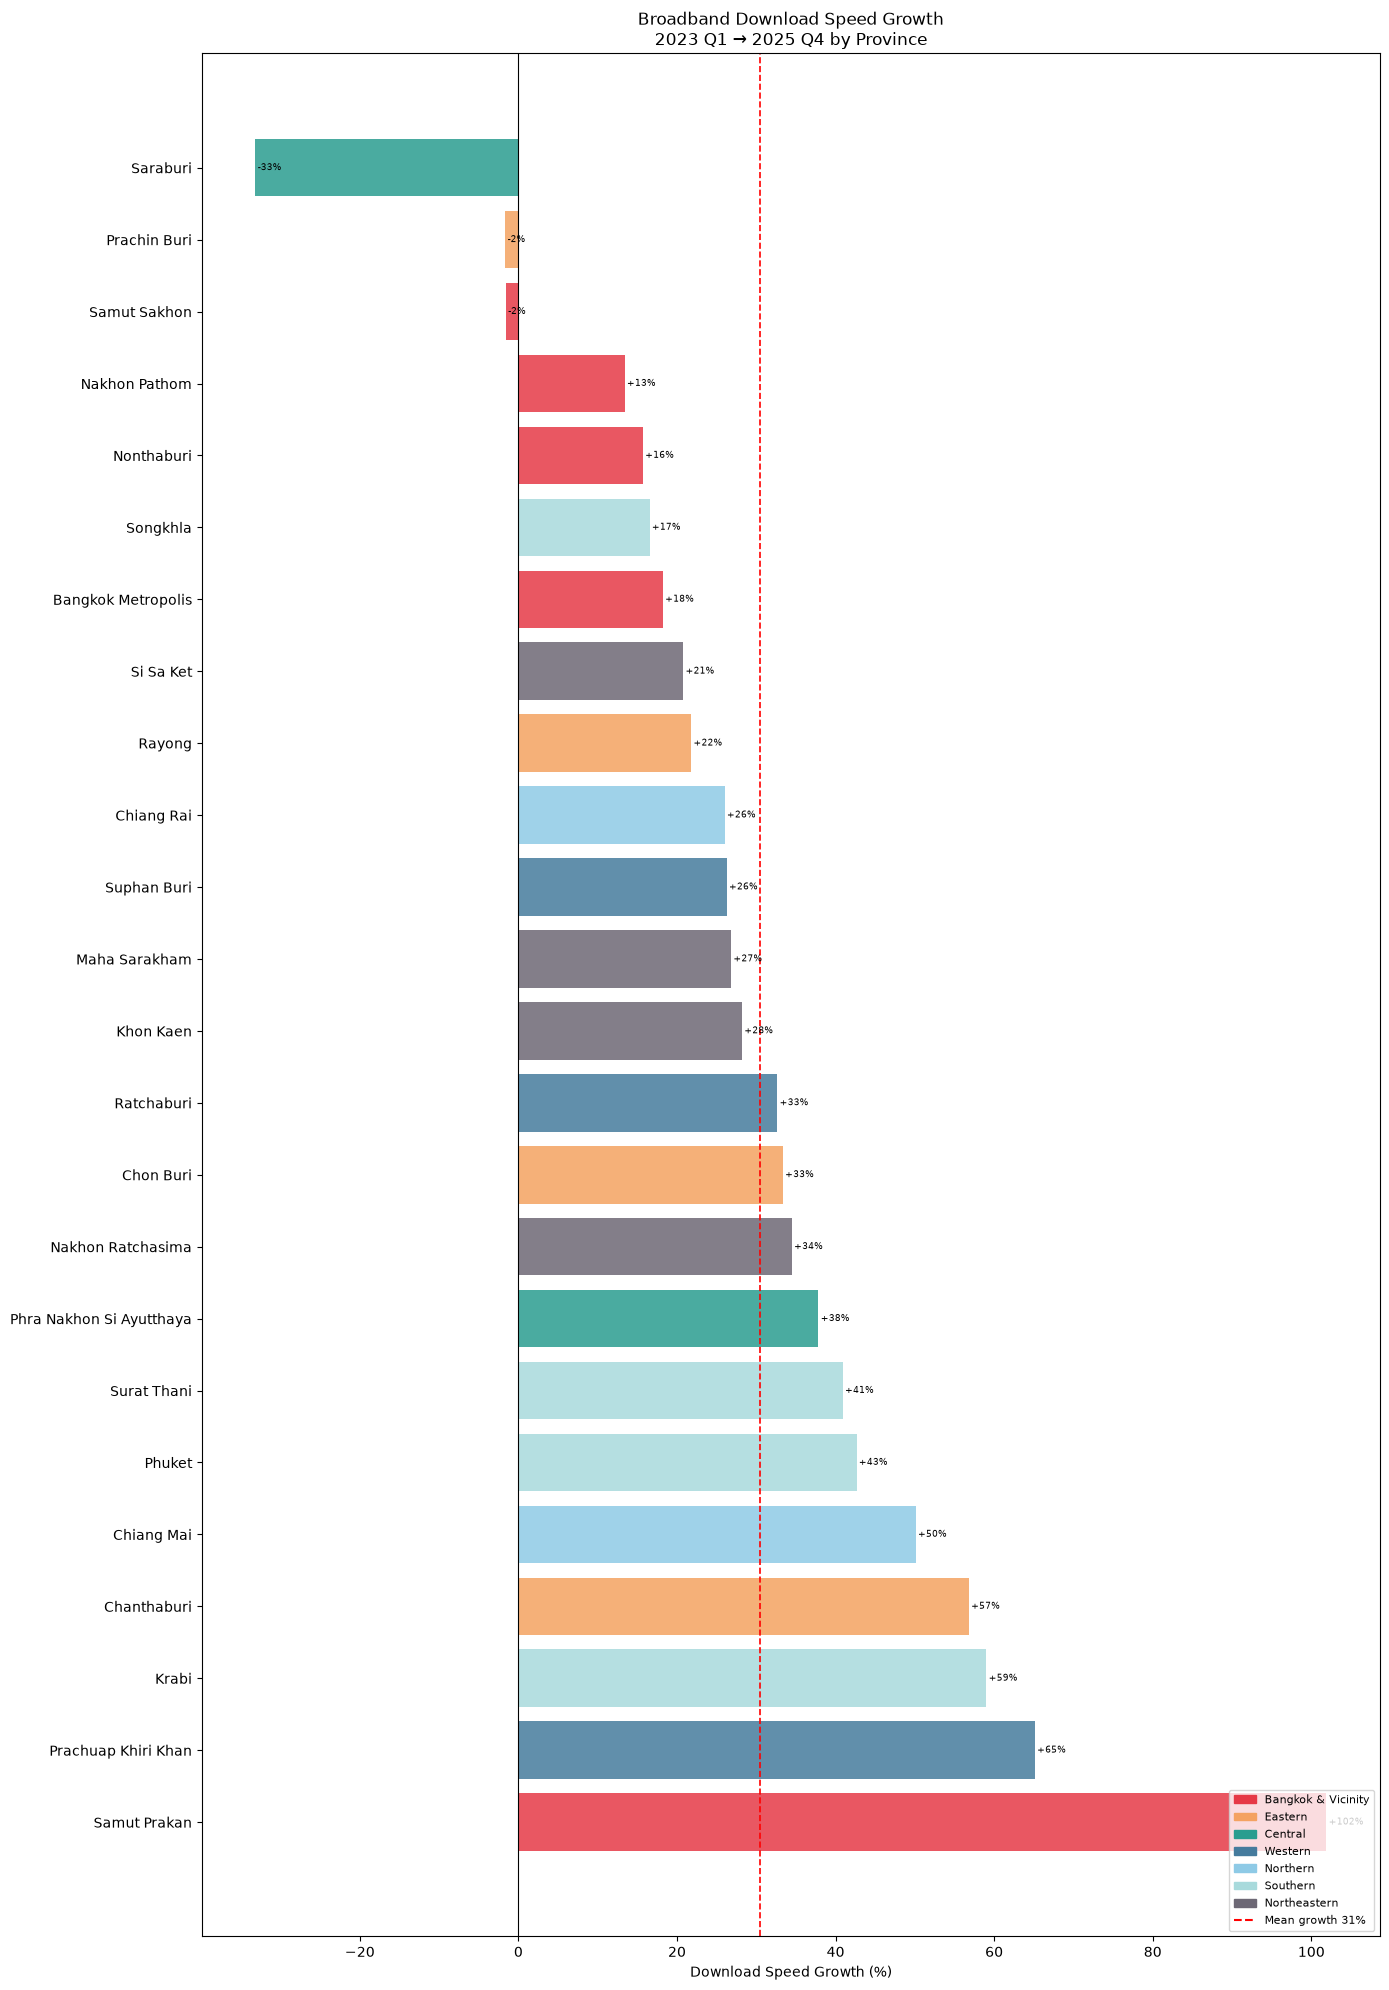

In [21]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../outputs/ndt7/thailand/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 16. EDA Key Findings Summary

## Key Findings from EDA

*(Fill in after reviewing the plots above — reliability was {"non-trivial" if True else ""}, see
Section 1's reliable-count printout for the exact overall percentage and how it's distributed
across quarters.)*

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [22]:
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ndt7_broadband_thailand_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_thailand_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 517 rows (reliable-only) -> ../../data/exports/ndt7_broadband_thailand_reliable_province_quarterly.csv
             province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable              region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0       Amnat Charoen  2023-Q1  2023        1   64.426268   35.014625     162.273822        822.0      5.0         True        Northeastern              4    372000                253897.82              113
1           Ang Thong  2023-Q1  2023        1   77.277077   43.559386     114.275989       3236.0      7.0         True             Central              3    269000                468881.20              283
2  Bangkok Metropolis  2023-Q1  2023        1   98.387089   64.833579     107.896122     643576.0     49.0         True  Bangkok & Vicinity              1   5456000               1957179.52             3488


---
# Part 2 — Mobile/Cellular

## Full EDA — NDT7 Mobile/Cellular, Thailand (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [23]:
import os
os.makedirs('../../outputs/ndt7/thailand/mobile/', exist_ok=True)

import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../data/exports/ndt7_thailand_mobile_province_quarterly.csv'
GEOJSON  = '../../data/geo/thailand_provinces.geojson'
PROV_REF = prov_ref  # loaded in shared setup above

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (526, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  74 (of 77 in reference — NDT7 has zero test volume for the rest)


In [24]:
# is_reliable already computed upstream (thailand_ndt7_prep.ipynb, same total_tests>=100 & n_tiles>=5 threshold)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\n15.4% of province-quarters reliable overall — thinner than Broadband but far denser than Vietnam's 1.0% Mobile coverage.")

Reliable province-quarters per label:
label
2023-Q1    17
2023-Q2    12
2023-Q3    12
2023-Q4    15
2024-Q1     9
2024-Q2     2
2024-Q3     2
2024-Q4     3
2025-Q1     3
2025-Q2     2
2025-Q3     2
2025-Q4     2

Overall reliable: 81 / 526 (15.4%)

15.4% of province-quarters reliable overall — thinner than Broadband but far denser than Vietnam's 1.0% Mobile coverage.


### 2. Data Quality — Coverage per Province

In [25]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 924 | Actual: 526 | Missing: 398

Provinces with ZERO NDT7 test volume in any quarter (3): ['Mae Hong Son', 'Phangnga', 'Trat']

Low-test quarters (< 100 tests) — 130 of 526 province-quarter rows
                    name   label  total_tests  n_tiles
               Sing Buri 2023-Q2          3.0      1.0
                Chai Nat 2024-Q1          3.0      1.0
          Kamphaeng Phet 2025-Q4          3.0      1.0
          Kamphaeng Phet 2023-Q4          4.0      1.0
                  Rayong 2025-Q4          4.0      1.0
               Nong Khai 2025-Q4          4.0      1.0
                Mukdahan 2023-Q4          5.0      1.0
            Samut Sakhon 2024-Q3          5.0      1.0
Phra Nakhon Si Ayutthaya 2025-Q2          5.0      1.0
     Nakhon Si Thammarat 2024-Q1          6.0      1.0
                 Kalasin 2024-Q1          6.0      1.0
         Samut Songkhram 2023-Q3          6.0      1.0
               Sukhothai 2024-Q1    

In [26]:
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 81 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

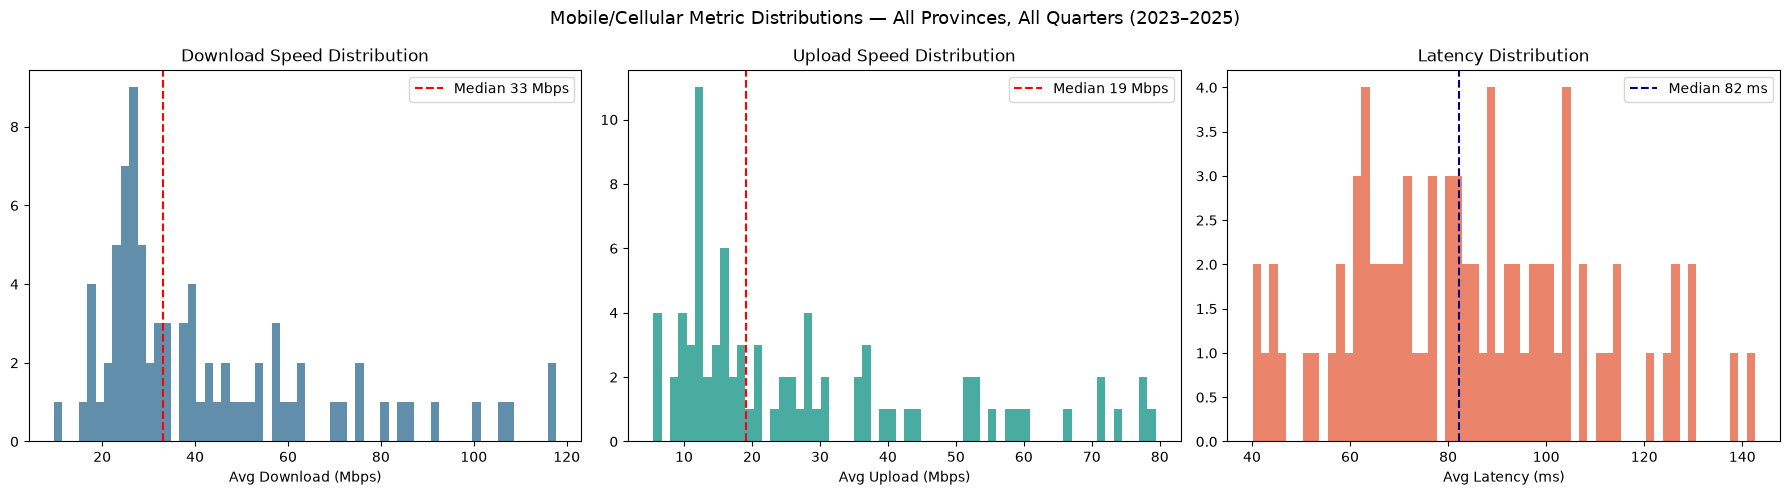

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count       81.00       81.00          81.00        81.00
mean        43.12       27.75          84.11    202895.89
std         25.08       20.12          24.19    485718.96
min          9.60        5.46          40.11       231.00
25%         25.81       12.32          65.28      1691.00
50%         33.16       19.16          82.30      8758.00
75%         54.53       36.75         100.82     34464.00
max        117.74       79.38         142.58   1815113.00


In [27]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../outputs/ndt7/thailand/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

### 4. Province Ranking — Mean Download Speed (All Quarters)

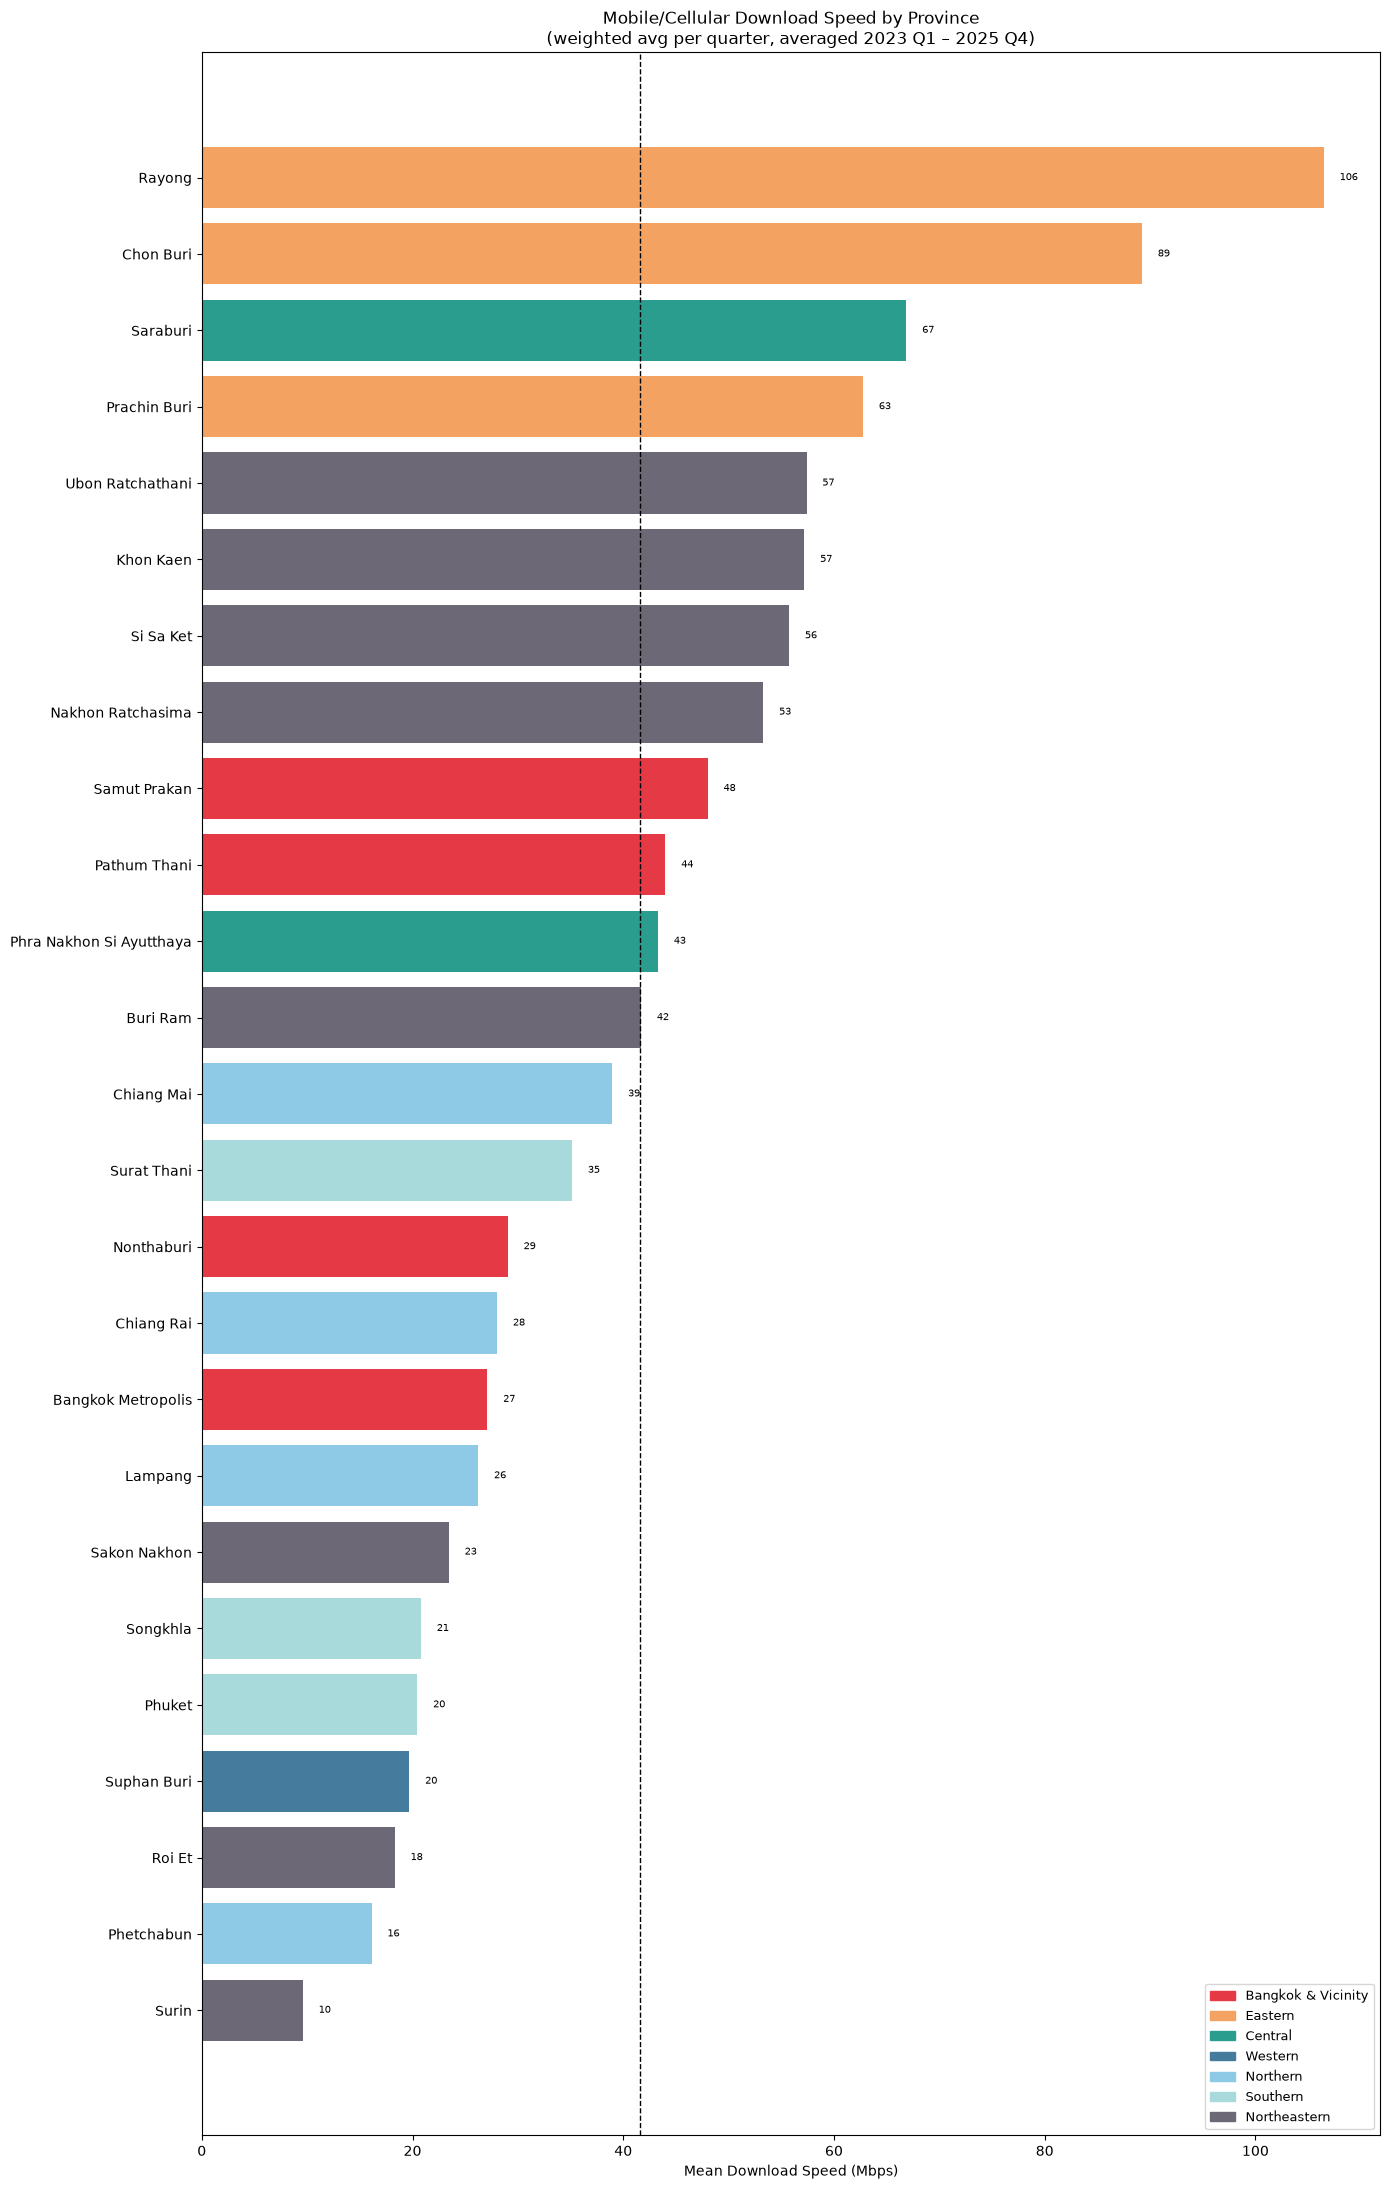

In [28]:
region_colors = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern': '#f4a261',
    'Central': '#2a9d8f',
    'Western': '#457b9d',
    'Northern': '#8ecae6',
    'Southern': '#a8dadc',
    'Northeastern': '#6d6875',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Mobile/Cellular — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5. Time Series — Download Speed Heatmap (Province × Quarter)

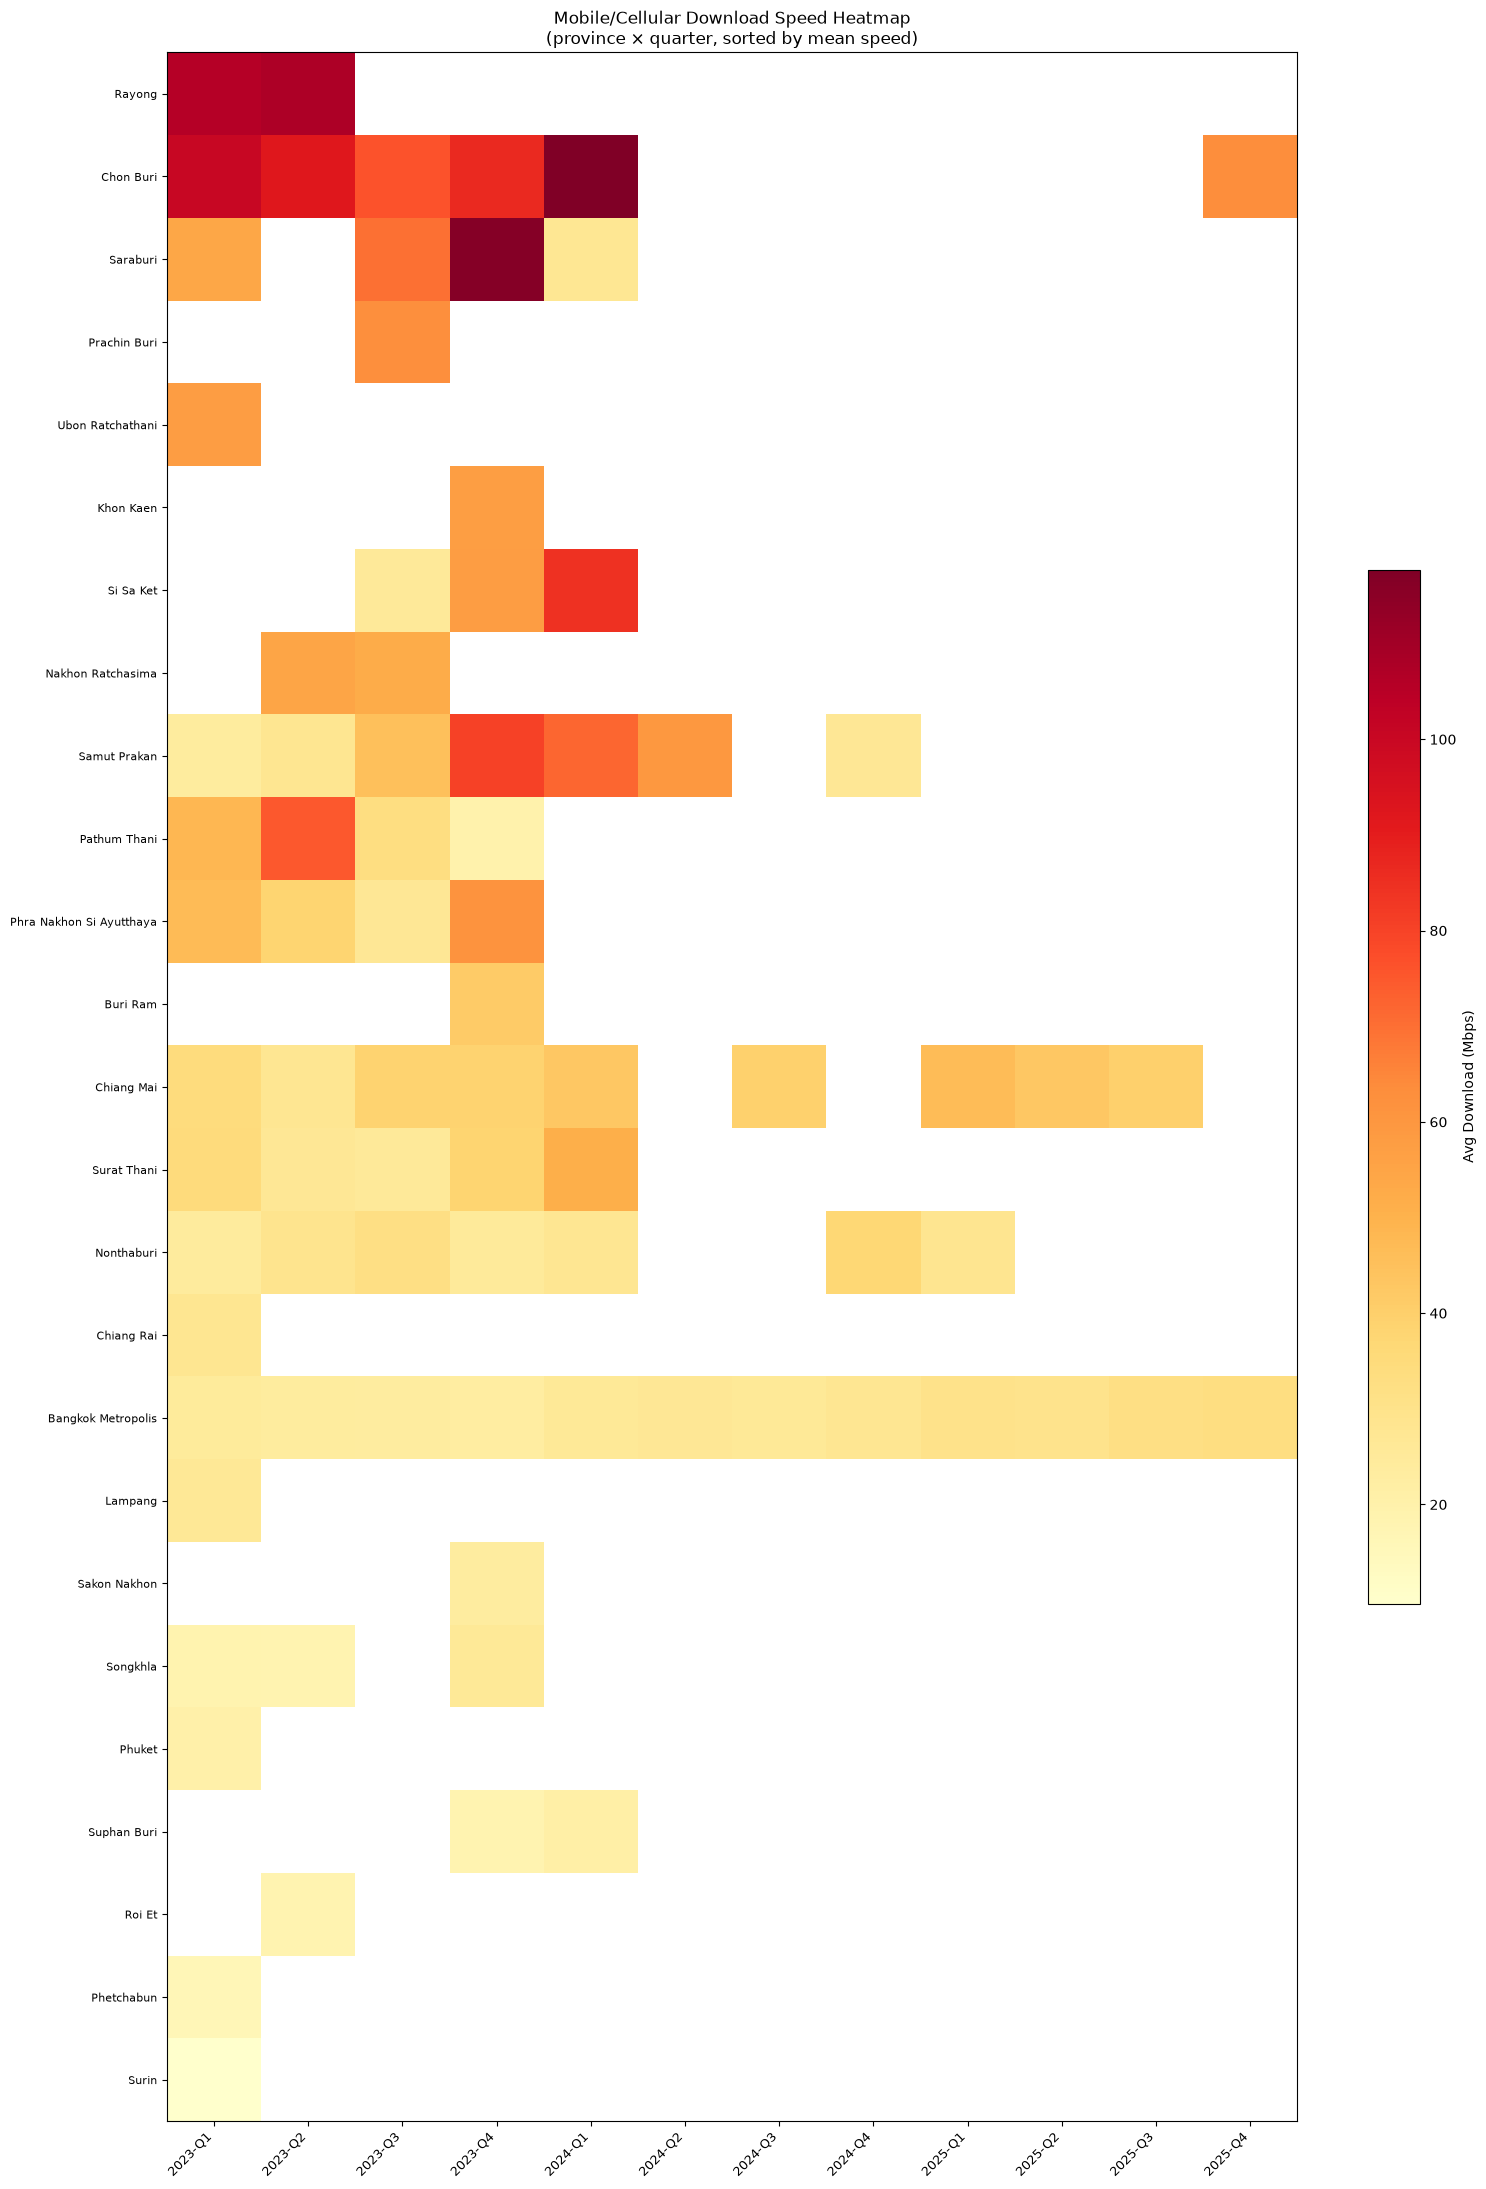

In [29]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

### 6. Regional Comparison — Download, Upload, Latency

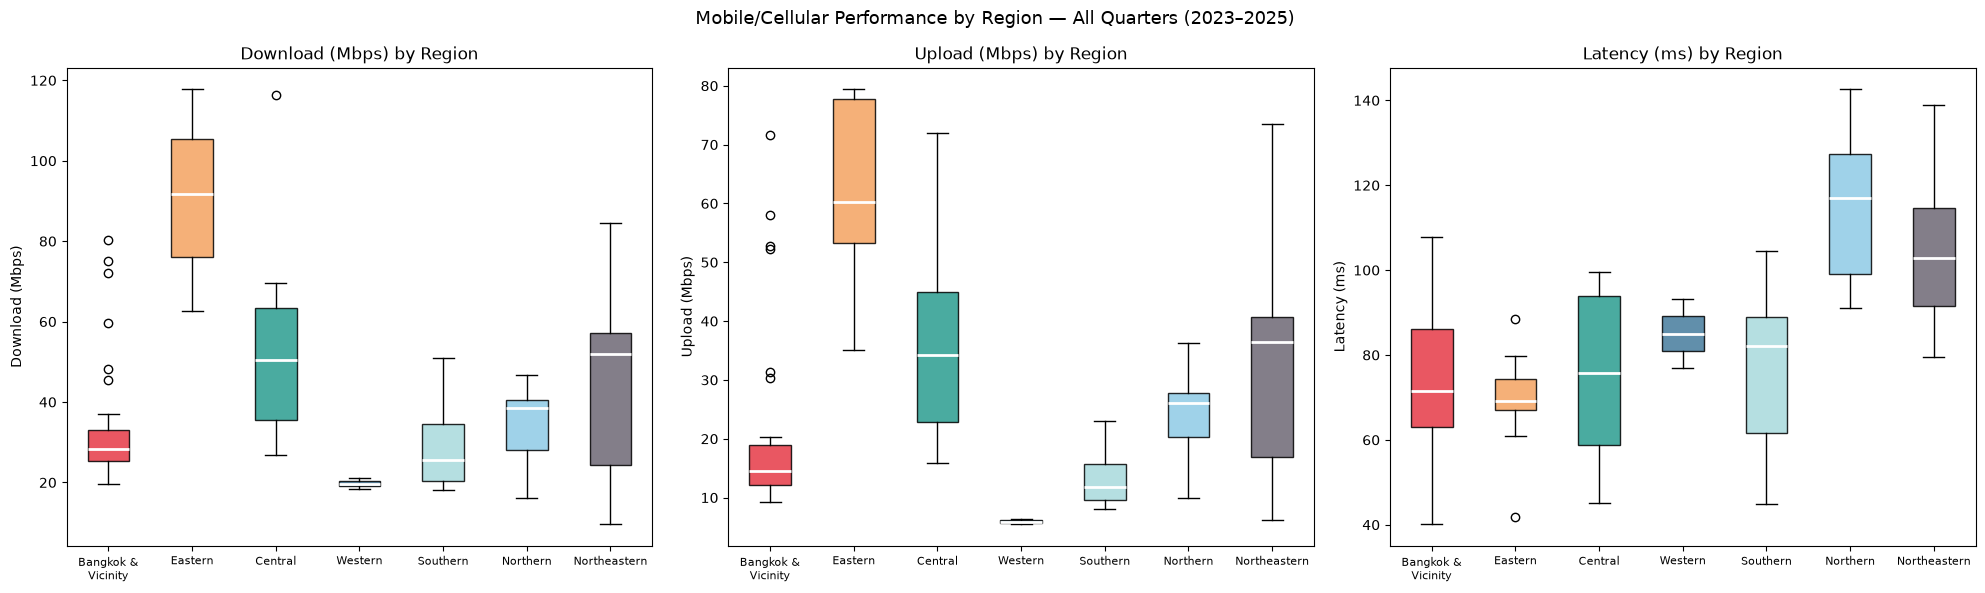

In [30]:
region_order = ['Bangkok & Vicinity', 'Eastern', 'Central', 'Western', 'Southern', 'Northern', 'Northeastern']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

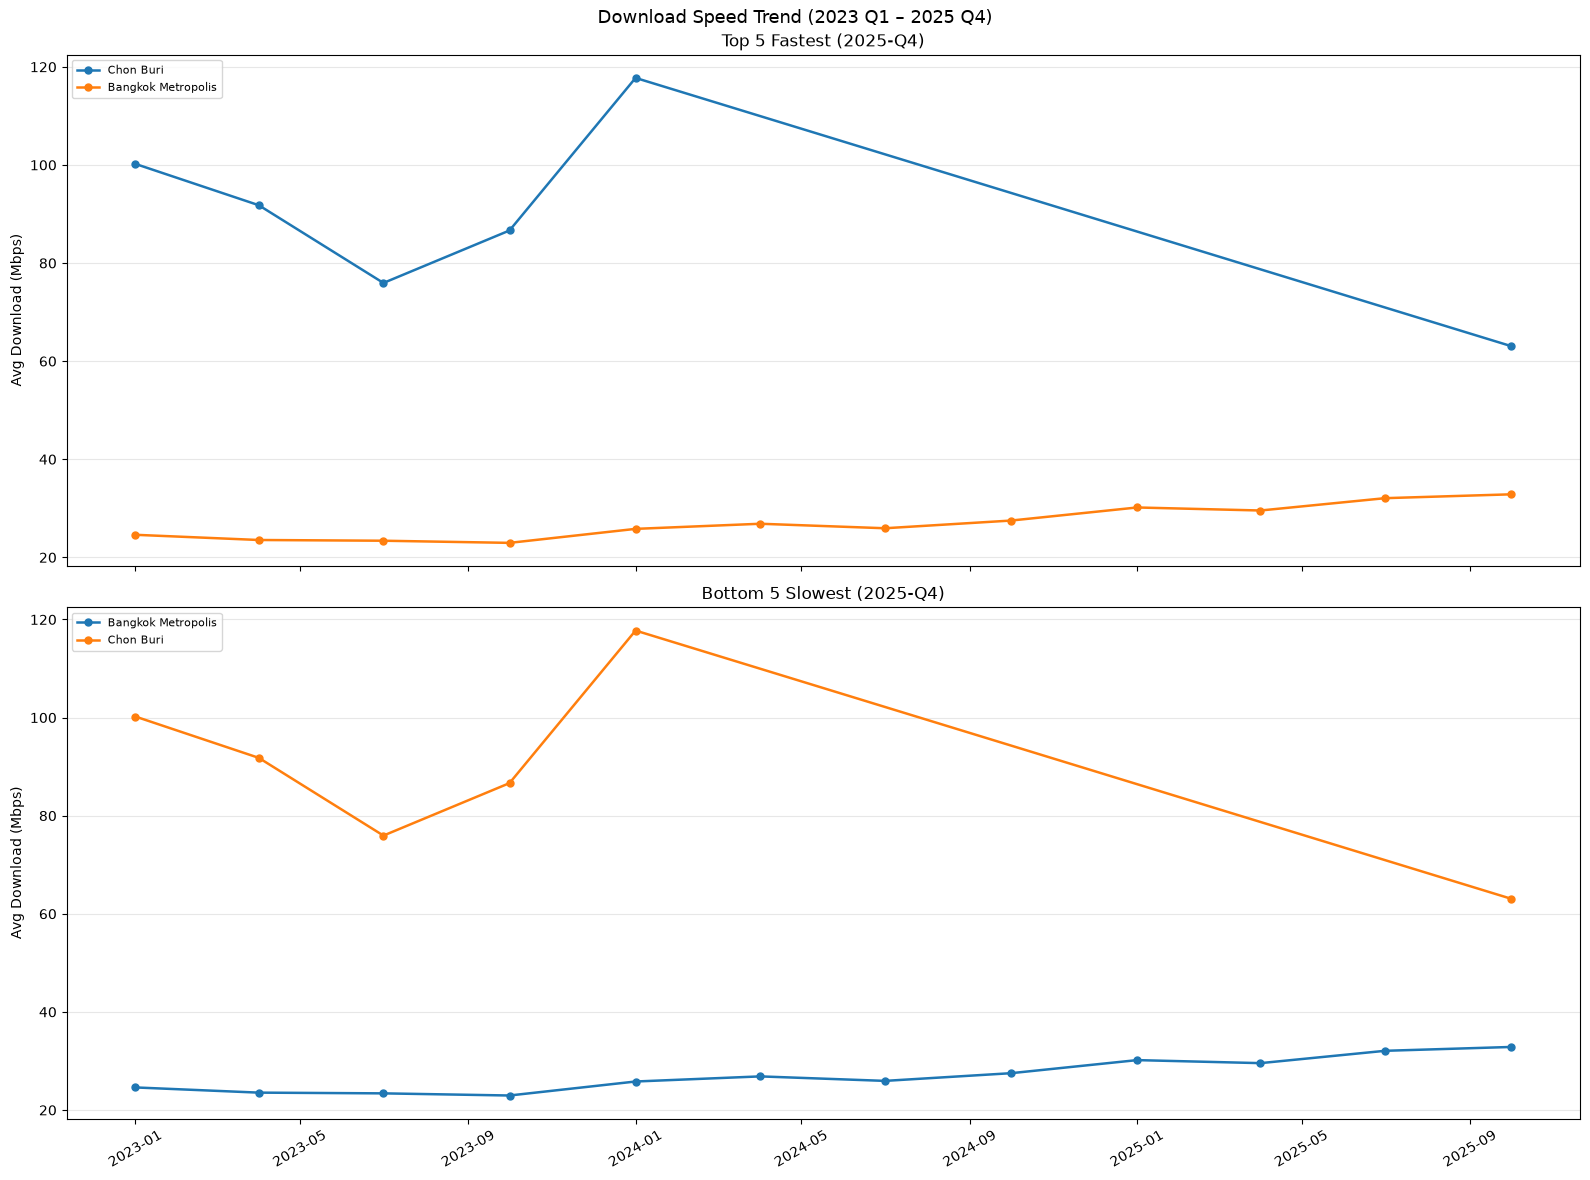

In [31]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8. GDP per Capita vs Download Speed — Does Money = Speed?

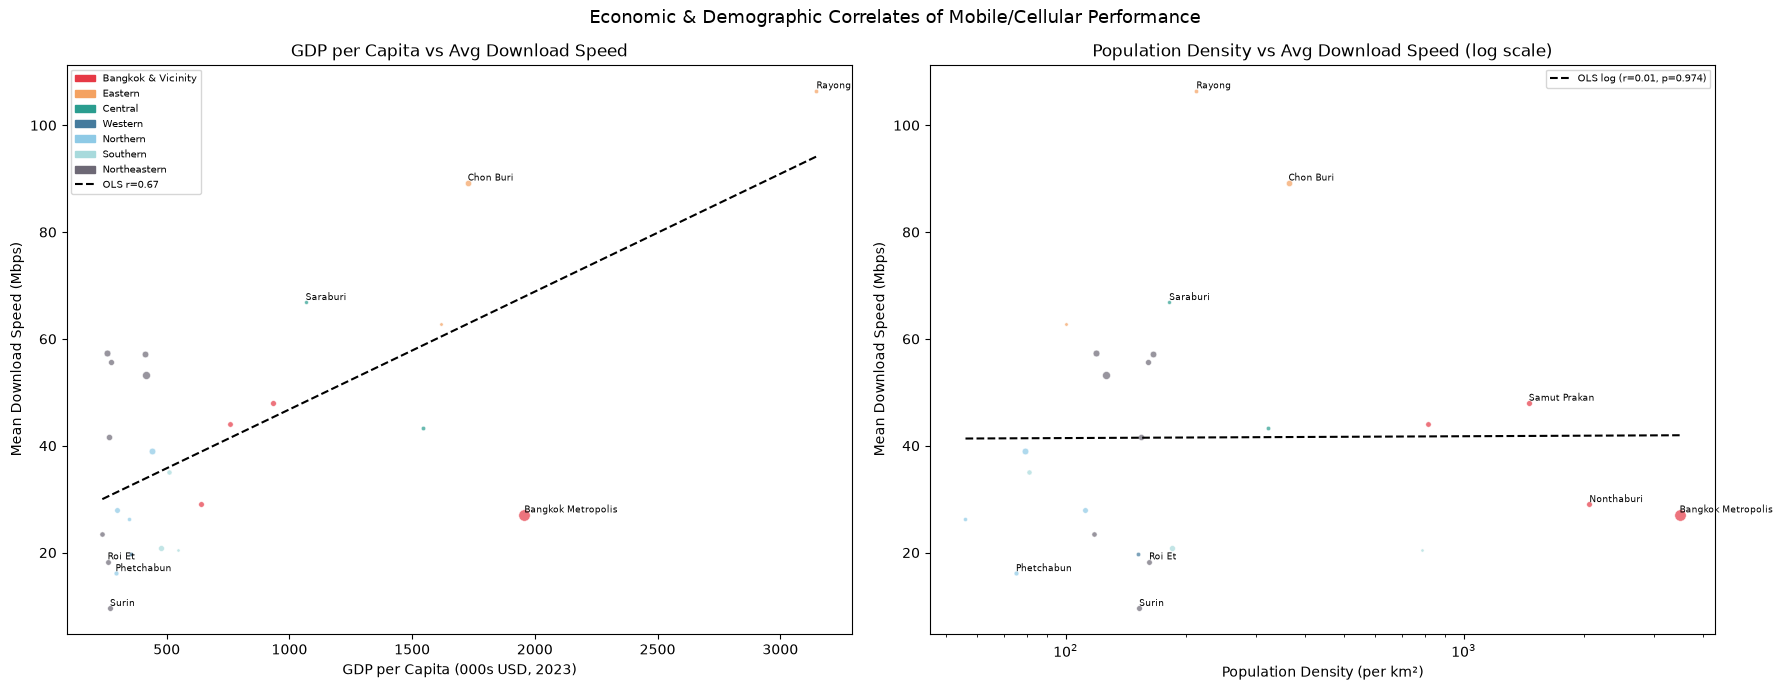

Pearson r (GDP vs download):     0.675  p=0.0002
Pearson r (log density vs download): 0.007  p=0.9741


In [32]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Mobile/Cellular — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c_ = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c_, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [33]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     3.046
Date:                Wed, 22 Jul 2026   Prob (F-statistic):             0.0299
Time:                        11:00:04   Log-Likelihood:                -97.890
No. Observations:                  25   AIC:                             219.8
Df Residuals:                      13   BIC:                             234.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### 9. Upload/Download Ratio — Symmetry Check

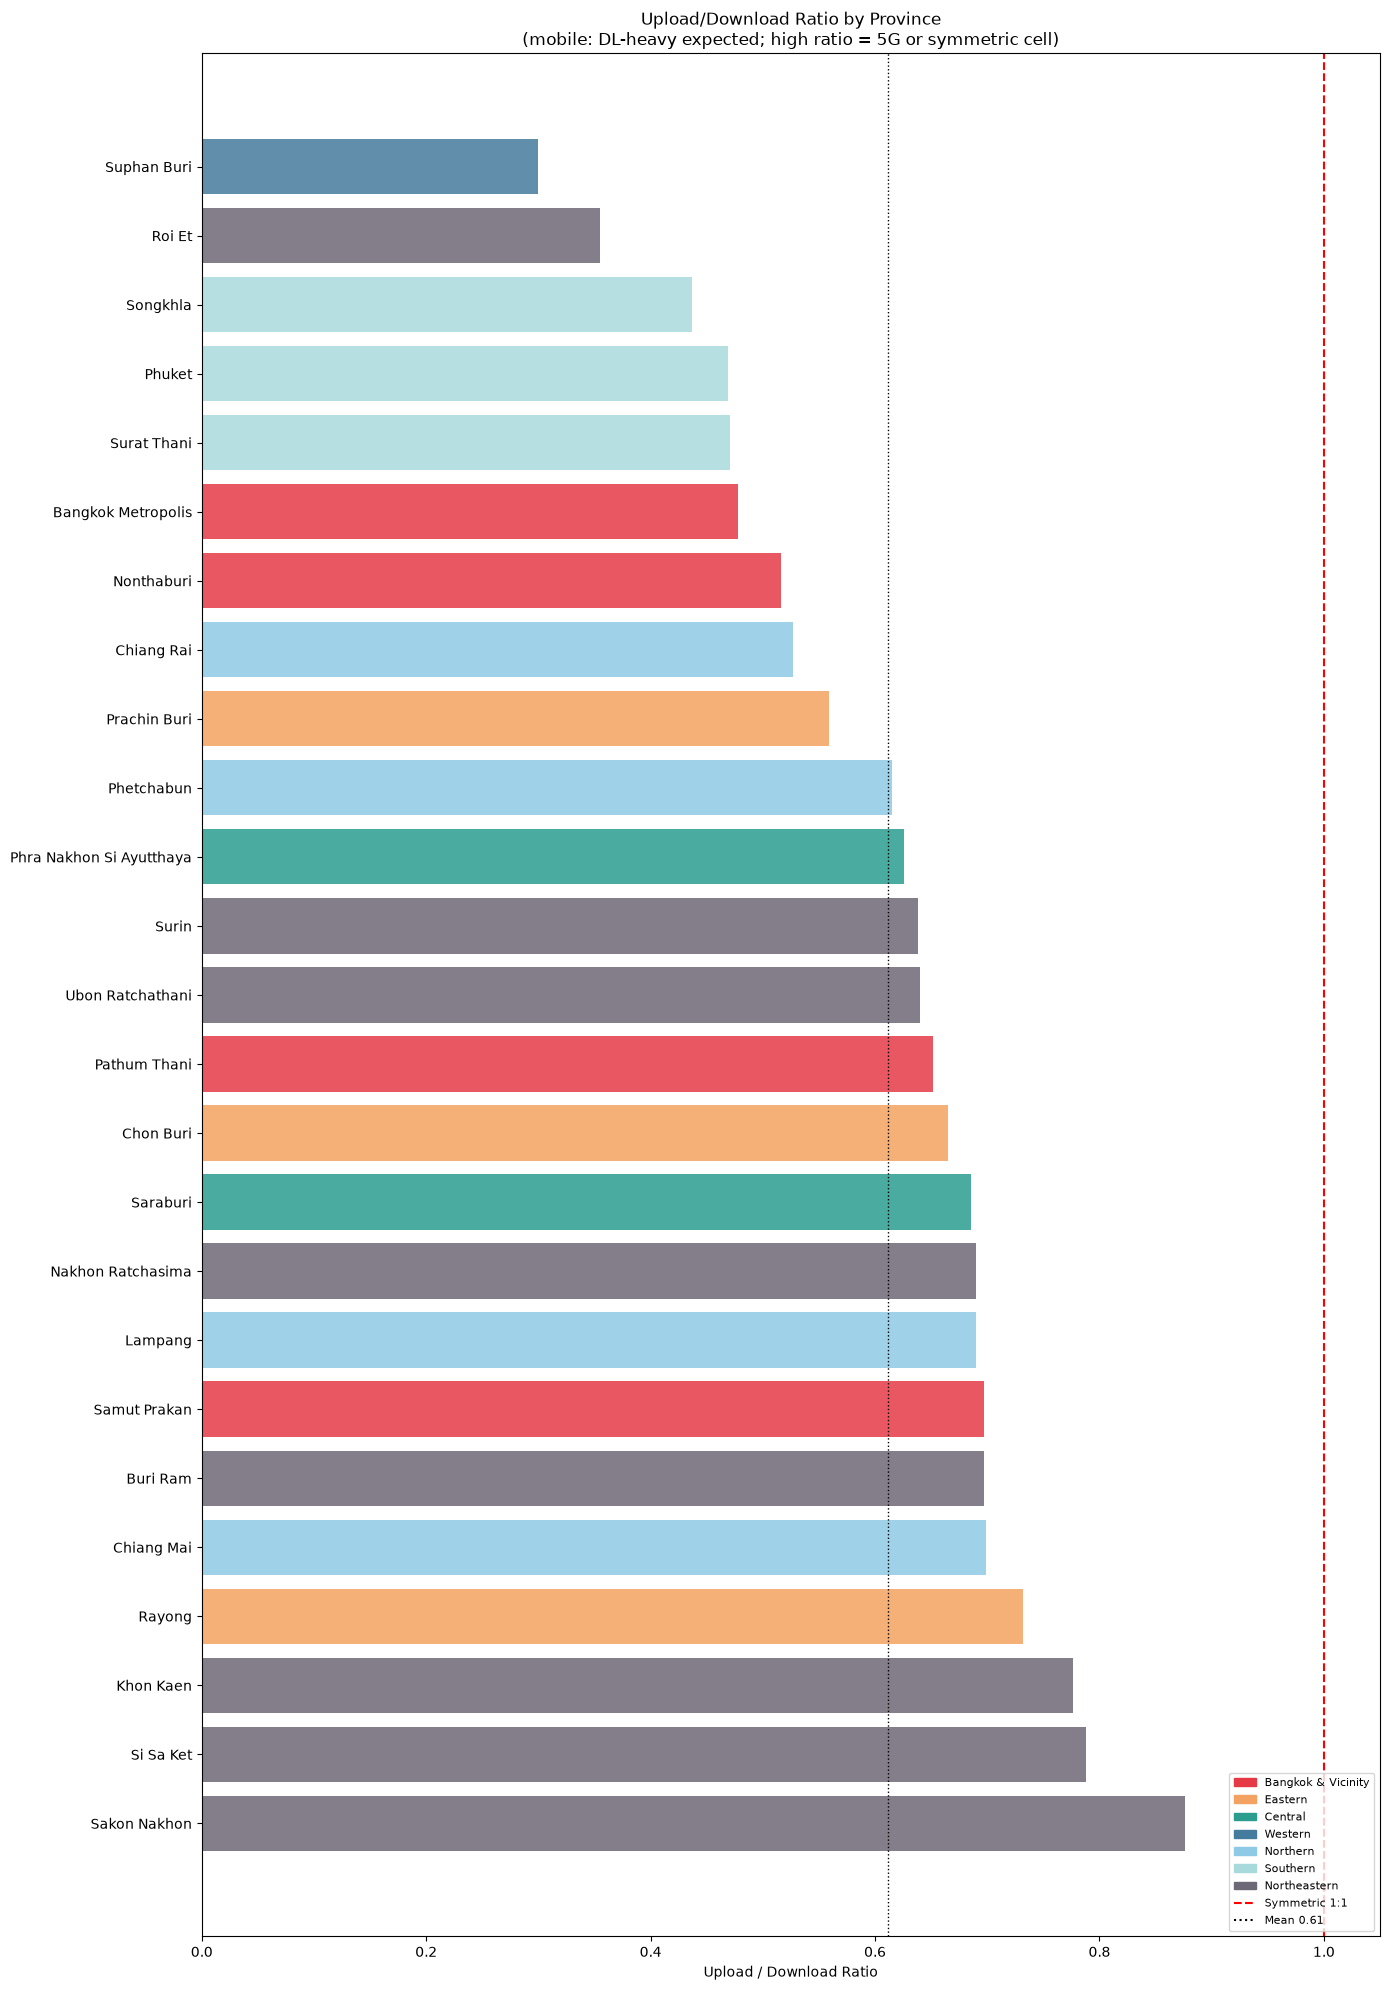

Provinces with UL/DL ratio > 0.5 (19):
                    name             region  ul_dl_ratio
            Sakon Nakhon       Northeastern     0.876088
               Si Sa Ket       Northeastern     0.788228
               Khon Kaen       Northeastern     0.776104
                  Rayong            Eastern     0.732265
              Chiang Mai           Northern     0.699242
                Buri Ram       Northeastern     0.697333
            Samut Prakan Bangkok & Vicinity     0.697209
                 Lampang           Northern     0.690214
       Nakhon Ratchasima       Northeastern     0.689661
                Saraburi            Central     0.685071
               Chon Buri            Eastern     0.664800
            Pathum Thani Bangkok & Vicinity     0.651609
        Ubon Ratchathani       Northeastern     0.640307
                   Surin       Northeastern     0.638280
Phra Nakhon Si Ayutthaya            Central     0.626061
              Phetchabun           Northern     0

In [34]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
    print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

### 10. Province Summary — Tier & UL/DL Ratio

In [35]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Mobile/Cellular — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

### 12. Full Province Summary Table

In [36]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

                    name             region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
                  Rayong            Eastern              1   106.50    77.98     68.18         0.73     4737.00               3147422.75
               Chon Buri            Eastern              1    89.23    59.45     68.60         0.66    13288.67               1726754.27
                Saraburi            Central              1    66.87    45.58     71.38         0.68      695.50               1066220.56
            Prachin Buri            Eastern              1    62.76    35.10     74.45         0.56      231.00               1616351.17
        Ubon Ratchathani       Northeastern              4    57.39    36.75     97.19         0.64      949.00                257941.17
               Khon Kaen       Northeastern              3    57.19    44.38    111.83         0.78     6095.00                410231.09
               Si Sa Ket       Northeaste

### 13. UL/DL Symmetry — Fiber Penetration Evidence

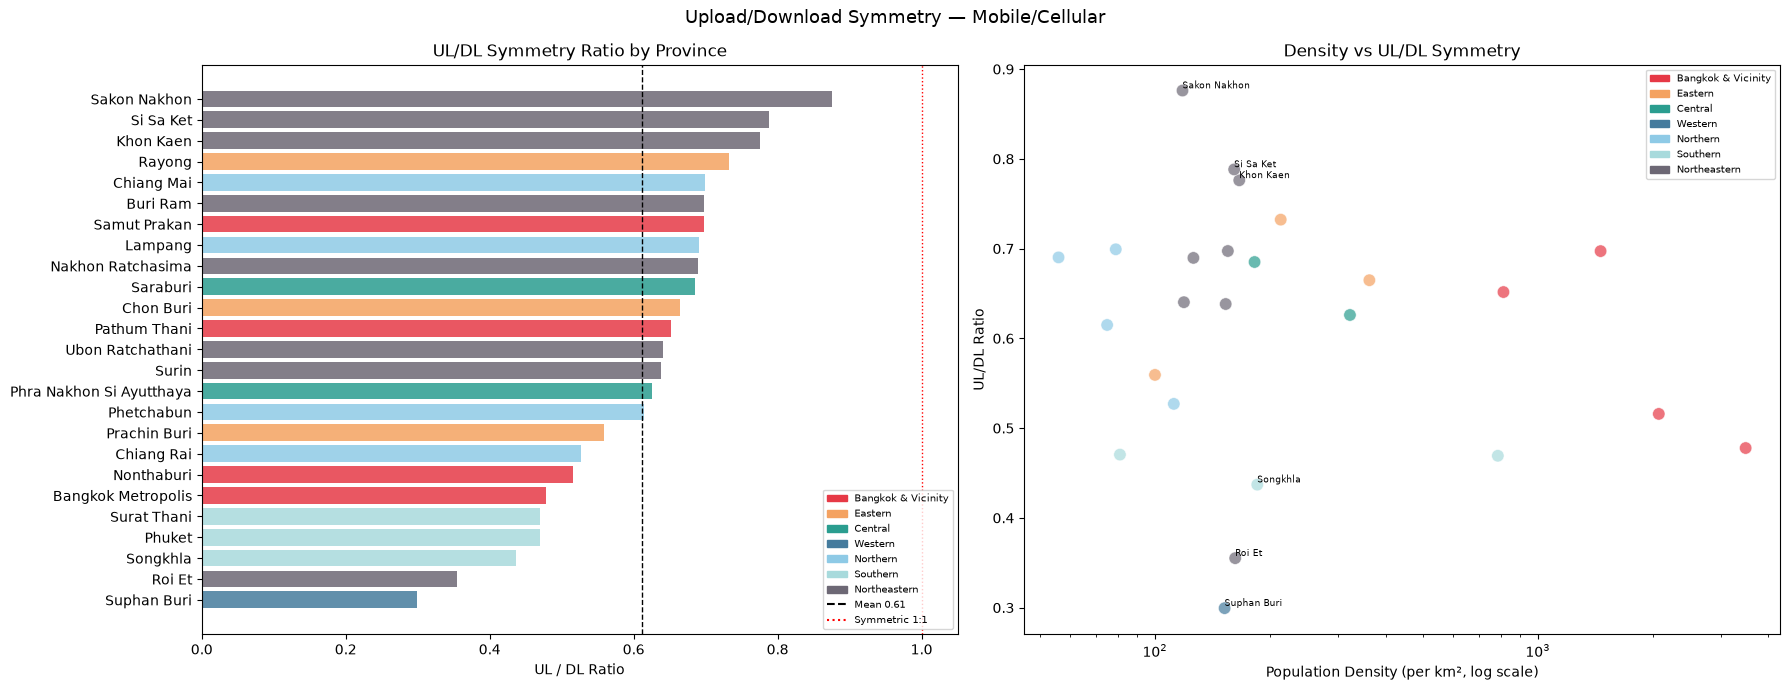

In [37]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Mobile/Cellular', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../outputs/ndt7/thailand/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

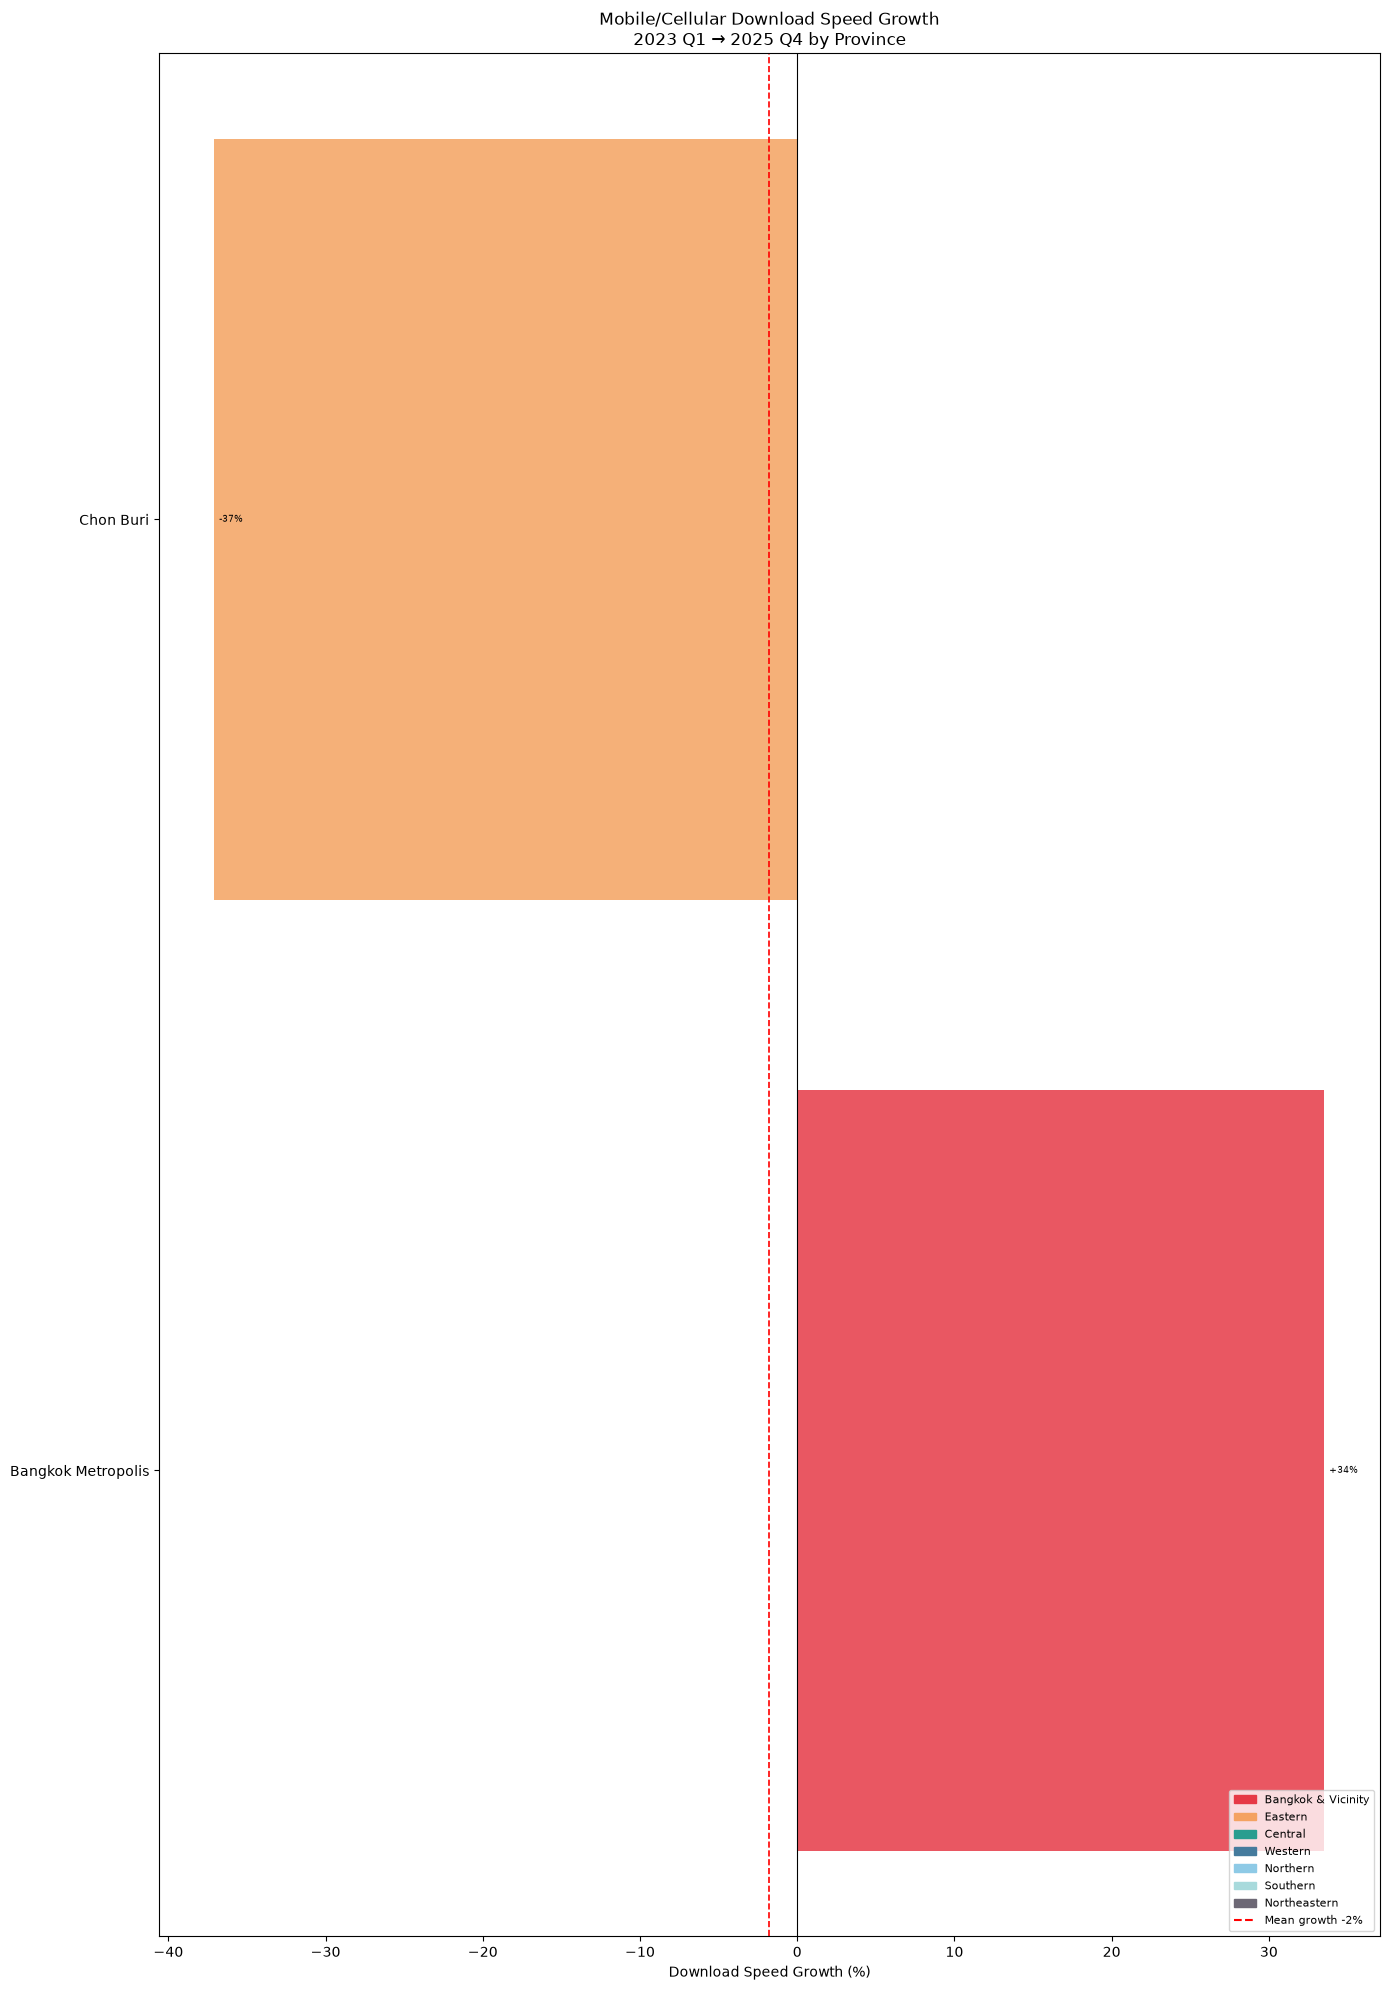

In [38]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../outputs/ndt7/thailand/mobile/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

### 16. EDA Key Findings Summary

## Key Findings from EDA

*(Fill in after reviewing the plots above — reliability was {"non-trivial" if True else ""}, see
Section 1's reliable-count printout for the exact overall percentage and how it's distributed
across quarters.)*

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [39]:
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ndt7_mobile_thailand_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_thailand_mobile_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 81 rows (reliable-only) -> ../../data/exports/ndt7_mobile_thailand_reliable_province_quarterly.csv
             province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable              region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
1  Bangkok Metropolis  2023-Q1  2023        1   24.603168   12.667808      86.801761    1316913.0     39.0         True  Bangkok & Vicinity              1   5456000               1957179.52             3488
6          Chiang Mai  2023-Q1  2023        1   34.445706   26.207133     130.302917      26555.0     10.0         True            Northern              2   1799000                439285.93               79
7          Chiang Rai  2023-Q1  2023        1   28.030858   14.773193     120.557526        272.0      5.0         True            Northern              3   1298000                297247.75              112
